In [1]:
from collections import Counter, defaultdict
from functools import partial
from multiprocessing import Pool
from pathlib import Path
from pickle import dump, load
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import polars.selectors as cs
import seaborn as sns
from scipy.stats import pearsonr, spearmanrho
from sklearn.linear_model import (
    LogisticRegressionCV,
)
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedGroupKFold,
    cross_val_predict,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.utils import resample


In [2]:
cache_dir = Path("/orcd/data/manoli/001/rcalef/projects/vep_comparisons/")
data_dir = Path("/orcd/data/manoli/001/rcalef/data/vep_comparisons/variants")
variants_path = data_dir / "collated_variants.annotated.tsv.gz"

esmc_scores_path = Path(
    "/orcd/data/manoli/001/rcalef/projects/vep_comparisons/scoring/collated_variants.esmc_300m.tsv.gz"
)

saprot_scores_path = Path(
    "/orcd/data/manoli/001/rcalef/projects/vep_comparisons/scoring/collated_variants.saprot_650m.tsv.gz"
)

# Evo2 scores present as sharded parquet files in different directories
# for different variant datasets.
evo_dir = Path("/orcd/data/manoli/001/iychan25/evo2-clinvar/results/scores_export/")
evo_score_globs = {
    "finucane_v50": "scores_chunk*",
    "multisusie": "scores_chunk*",
    "eqtl": "scores_chunk*",
    "clinvar": "scores_relabeled.parquet",
}

# RiNaLMo scores present as separate parquet files per dataset.
rinalmo_dir = Path("/orcd/data/manoli/001/laurieee/new-evaluation/results/annotated/")
rinalmo_files = [
    "clinvar_annotated.parquet",
    "gwas_annotated.parquet",
    "eqtl_annotated.parquet",
]

dataset_labels = {
    # "ukbb": ["high_pip"],
    # "multisusie": ["high_pip"],
    "gwas": ["high_pip"],
    "eqtl": ["high_pip"],
    "clinvar": ["Pathogenic", "Likely_pathogenic"],
}

dataset_names: dict[str, str] = {"gwas": "GWAS", "eqtl": "eQTL", "clinvar": "ClinVar"}

annot_names = {
    "gnocchi_z": "Gnocchi",
    "phylop": "PhyloP",
    # "roulette_mr": "Roulette MR",
    "log_roulette_mr": "log(Roulette MR)",
    "gnomadg_af_log": "log(MAF)",
}

model_names = {
    "evo_score": "Evo2",
    "saprot_score": "SaProt",
    "rinalmo_score": "RiNALMo",
    "esmc_score": "ESM-C",
}

pretty_names = {}
pretty_names.update(annot_names)
pretty_names.update(model_names)

In [3]:
_ = pl.Config.set_tbl_rows(15)

## Load all data

Load and merge the following:
- Variants w/ annotations (PhyloP, Gnocchi, Roulette)
    - Create merged "GWAS" group that combines UKBB/Finucane and MultiSuSiE
- Model scores for variant positions
    - ESM-C: protein-coding missense variants only
    - Evo2 (partial): p(ref), p(alt), log-likelihood ratio. Both averaged over forward and reverse direction
    - RiNALMo

In [19]:
# Load variants w/ annotations
df = (
    pl.read_csv(
        variants_path,
        separator="\t",
        null_values="-",
        schema_overrides={
            "multisusie_pip": pl.Float64,
            "eqtl_pip": pl.Float64,
        },
    )
    .with_columns(
        gnomadg_af_log=(
            pl.when(pl.col("gnomadg_af") == 0)
            .then(None)
            .otherwise(pl.col("gnomadg_af").log10())
        ),
        log_roulette_mr=pl.col("roulette_mr").log10(),
        gwas_pip=pl.max_horizontal(pl.col("ukbb_pip", "multisusie_pip")),
    )
    .with_columns(
        gwas_label=(
            pl.when(pl.col("gwas_pip") >= 0.5)
            .then(pl.lit("high_pip"))
            .otherwise(
                pl.when(pl.col("gwas_pip").is_null())
                .then(None)
                .otherwise(pl.lit("low_pip"))
            )
        )
    )
)

print(df.shape)
df.head()

(340507, 42)


variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log,log_roulette_mr,gwas_pip,gwas_label
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,str
"""chr1:834583:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",834582,834583,204,null,null,null,0.1158,0.3403,0.004209,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.612,null,1.273,null,"""low""",-0.936291,0.104828,0.004209,"""low_pip"""
"""chr1:835506:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",835505,835506,113,null,null,null,0.1093,0.3085,0.004478,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-2.742,null,2.12,null,"""low""",-0.96138,0.326336,0.004478,"""low_pip"""
"""chr1:841852:C:T""","""ENSG00000228794""","""chr1""","""C""","""T""","""ENST00000415295""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""SAS""",841851,841852,726,null,null,0.0843,0.06921,0.1493,0.003612,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.459,null,0.094,null,"""low""",-1.159831,-1.026872,0.003612,"""low_pip"""
"""chr1:856473:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""gnomADe_FIN""",856472,856473,2884,null,null,0.07955,0.07915,0.1923,0.002221,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.166,1.535938,0.105,null,"""low""",-1.101549,-0.978811,0.002221,"""low_pip"""
"""chr1:858952:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""EAS""",858951,858952,5363,null,null,0.02083,0.09489,0.1607,0.002458,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.531,null,0.916,null,"""low""",-1.02278,-0.038105,0.002458,"""low_pip"""


In [20]:
def load_one_rinalmo(path: Path) -> pl.DataFrame:
    return (
        pl.read_parquet(
            path,
            columns=[
                "chrom",
                "pos",
                "ref",
                "alt",
                "transcript_id",
                "gene_id",
                "score_ref",
                "score_alt",
            ],
        )
        .with_columns(
            variant=pl.format("chr{}:{}:{}:{}", "chrom", "pos", "ref", "alt"),
            gene=pl.col("gene_id").str.split(".").list[0],
            feature=pl.col("transcript_id").str.split(".").list[0],
            # Do log p(alt) - log p(ref) to have a "pathogenicity" score
            rinalmo_score=pl.col("score_ref") - pl.col("score_alt"),
        )
        .drop(
            "chrom",
            "pos",
            "ref",
            "alt",
            "gene_id",
            "transcript_id",
            "score_ref",
            "score_alt",
        )
    )


all_rinalmo_scores = pl.concat(
    [load_one_rinalmo(rinalmo_dir / filename) for filename in rinalmo_files]
).unique("variant")
all_rinalmo_scores.shape

(404803, 4)

In [21]:
# Load ESM-C scores for protein-coding missense variants
esmc_scores = (
    pl.read_csv(
        esmc_scores_path,
        separator="\t",
    )
    # Original scores are log(ref) - log(alt), so negate
    # so we have "pathogenicity" scores instead of
    # "tolerability" scores.
    .with_columns(score=-pl.col("score"))
    .rename({"score": "esmc_score"})
    .select("variant", "gene", "feature", "esmc_score")
)
print(esmc_scores.shape)
esmc_scores.head()

(48491, 4)


variant,gene,feature,esmc_score
str,str,str,f64
"""chr1:930248:G:A""","""ENSG00000187634""","""ENST00000616016""",-1.686048
"""chr1:930312:C:G""","""ENSG00000187634""","""ENST00000616016""",-0.110479
"""chr1:943896:A:G""","""ENSG00000187634""","""ENST00000455979""",-1.41601
"""chr1:946538:G:A""","""ENSG00000188976""","""ENST00000327044""",1.404949
"""chr1:971389:C:A""","""ENSG00000187583""","""ENST00000379410""",-0.172407


In [22]:
# Load SaProt scores for protein-coding missense variants in protein
# isoforms with available structures from AFDB
saprot_scores = (
    pl.read_csv(
        saprot_scores_path,
        separator="\t",
    )
    # Original scores are log(ref) - log(alt), so negate
    # so we have "pathogenicity" scores instead of
    # "tolerability" scores.
    .with_columns(score=-pl.col("score"))
    .rename({"score": "saprot_score"})
    .select("variant", "gene", "feature", "saprot_score")
)
print(saprot_scores.shape)
saprot_scores.head()

(38290, 4)


variant,gene,feature,saprot_score
str,str,str,f64
"""chr1:946538:G:A""","""ENSG00000188976""","""ENST00000327044""",2.459828
"""chr1:971389:C:A""","""ENSG00000187583""","""ENST00000379410""",-0.03537
"""chr1:973289:G:A""","""ENSG00000187583""","""ENST00000379410""",1.703886
"""chr1:973858:G:C""","""ENSG00000187583""","""ENST00000379410""",-1.337345
"""chr1:973929:T:C""","""ENSG00000187583""","""ENST00000379410""",-0.14852


In [23]:
def load_one_evo(path: Path, glob: str) -> pl.DataFrame:
    evo_scores = (
        pl.concat([pl.read_parquet(path) for path in sorted(path.glob(glob))])
        .with_columns(chrom=pl.col("chrom").cast(pl.String))
        .with_columns(
            chrom=pl.when(pl.col("chrom").str.contains("chr"))
            .then(pl.col("chrom"))
            .otherwise(pl.format("chr{}", "chrom")),
            evo_ref_prob=pl.mean_horizontal(
                pl.col("score_ref_fwd").exp(), pl.col("score_ref_rev").exp()
            ),
            evo_alt_prob=pl.mean_horizontal(
                pl.col("score_alt_fwd").exp(), pl.col("score_alt_rev").exp()
            ),
        )
        .with_columns(
            variant=pl.format("{}:{}:{}:{}", "chrom", "pos", "ref", "alt"),
            evo_score=pl.col("evo_ref_prob").log() - pl.col("evo_alt_prob").log(),
        )
        .select(
            "variant",
            "evo_ref_prob",
            "evo_alt_prob",
            "evo_score",
        )
    )
    return evo_scores


all_evo_scores = pl.concat(
    [load_one_evo(evo_dir / name, glob) for (name, glob) in evo_score_globs.items()],
    how="diagonal",
).unique("variant")
all_evo_scores.shape

(469215, 4)

In [24]:
def merge_and_report(
    df: pl.DataFrame,
    oth: pl.DataFrame,
    on: list[str],
    name: str,
) -> pl.DataFrame:
    merged = df.join(oth, on=on, how="left")
    present = merged.get_column(f"{name}_score").is_not_null().sum()
    print(f"{name}: {len(oth)} -> {present} merged")
    return merged


model_dfs = {
    "evo": all_evo_scores,
    "rinalmo": all_rinalmo_scores,
    "esmc": esmc_scores,
    "saprot": saprot_scores,
}

for name, vals in model_dfs.items():
    cols = ["variant"] if name == "evo" else ["variant", "gene", "feature"]
    df = merge_and_report(df, vals, on=cols, name=name)

print(df.shape)
df.head()

evo: 469215 -> 319380 merged
rinalmo: 404803 -> 230795 merged
esmc: 48491 -> 48491 merged
saprot: 38290 -> 38290 merged
(340507, 48)


variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log,log_roulette_mr,gwas_pip,gwas_label,evo_ref_prob,evo_alt_prob,evo_score,rinalmo_score,esmc_score,saprot_score
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,str,f64,f64,f64,f64,f64,f64
"""chr1:834583:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",834582,834583,204,null,null,null,0.1158,0.3403,0.004209,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.612,null,1.273,null,"""low""",-0.936291,0.104828,0.004209,"""low_pip""",0.314054,0.314115,-0.000196,-1.25,null,null
"""chr1:835506:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",835505,835506,113,null,null,null,0.1093,0.3085,0.004478,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-2.742,null,2.12,null,"""low""",-0.96138,0.326336,0.004478,"""low_pip""",0.336628,0.33667,-0.000124,-0.375,null,null
"""chr1:841852:C:T""","""ENSG00000228794""","""chr1""","""C""","""T""","""ENST00000415295""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""SAS""",841851,841852,726,null,null,0.0843,0.06921,0.1493,0.003612,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.459,null,0.094,null,"""low""",-1.159831,-1.026872,0.003612,"""low_pip""",0.329573,0.329497,0.000231,1.25,null,null
"""chr1:856473:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""gnomADe_FIN""",856472,856473,2884,null,null,0.07955,0.07915,0.1923,0.002221,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.166,1.535938,0.105,null,"""low""",-1.101549,-0.978811,0.002221,"""low_pip""",0.318683,0.318626,0.000177,null,null,null
"""chr1:858952:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""EAS""",858951,858952,5363,null,null,0.02083,0.09489,0.1607,0.002458,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.531,null,0.916,null,"""low""",-1.02278,-0.038105,0.002458,"""low_pip""",0.306684,0.306683,0.000003,null,null,null


### Variant counts

In [25]:
df.head()

variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log,log_roulette_mr,gwas_pip,gwas_label,evo_ref_prob,evo_alt_prob,evo_score,rinalmo_score,esmc_score,saprot_score
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,str,f64,f64,f64,f64,f64,f64
"""chr1:834583:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",834582,834583,204,null,null,null,0.1158,0.3403,0.004209,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.612,null,1.273,null,"""low""",-0.936291,0.104828,0.004209,"""low_pip""",0.314054,0.314115,-0.000196,-1.25,null,null
"""chr1:835506:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",835505,835506,113,null,null,null,0.1093,0.3085,0.004478,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-2.742,null,2.12,null,"""low""",-0.96138,0.326336,0.004478,"""low_pip""",0.336628,0.33667,-0.000124,-0.375,null,null
"""chr1:841852:C:T""","""ENSG00000228794""","""chr1""","""C""","""T""","""ENST00000415295""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""SAS""",841851,841852,726,null,null,0.0843,0.06921,0.1493,0.003612,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.459,null,0.094,null,"""low""",-1.159831,-1.026872,0.003612,"""low_pip""",0.329573,0.329497,0.000231,1.25,null,null
"""chr1:856473:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""gnomADe_FIN""",856472,856473,2884,null,null,0.07955,0.07915,0.1923,0.002221,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.166,1.535938,0.105,null,"""low""",-1.101549,-0.978811,0.002221,"""low_pip""",0.318683,0.318626,0.000177,null,null,null
"""chr1:858952:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""EAS""",858951,858952,5363,null,null,0.02083,0.09489,0.1607,0.002458,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.531,null,0.916,null,"""low""",-1.02278,-0.038105,0.002458,"""low_pip""",0.306684,0.306683,0.000003,null,null,null


In [26]:
dataset_labels

{'gwas': ['high_pip'],
 'eqtl': ['high_pip'],
 'clinvar': ['Pathogenic', 'Likely_pathogenic']}

In [27]:
(
    df.with_columns(
        **{
            ds_name: pl.when(pl.col(f"{ds_name}_label").is_null())
            .then(None)
            .otherwise(
                pl.when(pl.col(f"{ds_name}_label").is_in(pos_labels))
                .then(pl.lit("pos"))
                .otherwise(pl.lit("neg"))
            )
            for ds_name, pos_labels in dataset_labels.items()
        }
    )
    .select(*dataset_labels.keys())
    .unpivot(variable_name="dataset", value_name="label")
    .pivot(on="dataset", values="dataset", aggregate_function="len")
    .filter(pl.col("label").is_not_null())
)

label,gwas,eqtl,clinvar
str,u32,u32,u32
"""neg""",125363,67312,142736
"""pos""",1734,11108,29125


In [28]:
(
    df.unique("variant")
    .with_columns(
        **{
            ds_name: pl.when(pl.col(f"{ds_name}_label").is_null())
            .then(None)
            .otherwise(
                pl.when(pl.col(f"{ds_name}_label").is_in(pos_labels))
                .then(pl.lit("pos"))
                .otherwise(pl.lit("neg"))
            )
            for ds_name, pos_labels in dataset_labels.items()
        }
    )
    .select(*dataset_labels.keys())
    .unpivot(variable_name="dataset", value_name="label")
    .pivot(on="dataset", values="dataset", aggregate_function="len")
    .filter(pl.col("label").is_not_null())
)

label,gwas,eqtl,clinvar
str,u32,u32,u32
"""neg""",122332,66461,140652
"""pos""",1685,10958,28776


## Correlations

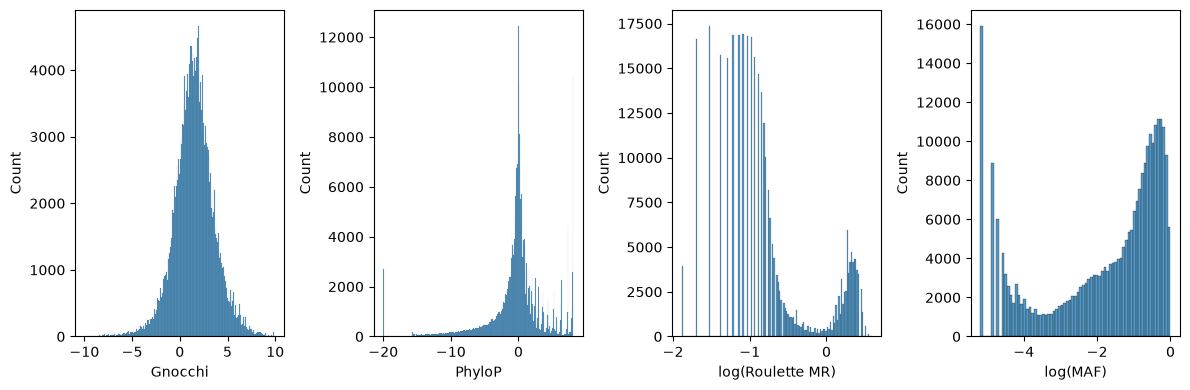

In [29]:
fig, axs = plt.subplots(
    nrows=1,
    ncols=len(annot_names),
    sharey=False,
    sharex=False,
    figsize=(12, 4),
)
for (annot, name), ax in zip(annot_names.items(), axs):
    sns.histplot(x=df.get_column(annot).drop_nulls(), ax=ax)
    ax.set_xlabel(name)
plt.tight_layout()

In [30]:
hist_color = "#3C6E71"
fit_color = "#D1495B"


def corr_model_vs_annotations(
    data: pl.DataFrame,
    model_col: str,
    annotations: dict[str, str] = annot_names,
    model_name: str | None = None,
    clip: bool = True,
):
    if model_name is None:
        model_name = model_col

    fig, axs = plt.subplots(
        nrows=1,
        ncols=len(annotations),
        sharex=False,
        figsize=(10, 4),
    )
    sns.despine(fig)

    if clip:
        scores = data.get_column(model_col).drop_nulls().to_numpy()
        ymin, ymax = np.quantile(scores, q=(0.001, 0.999))

    for i, ((annot, name), ax) in enumerate(zip(annotations.items(), axs)):
        plot_data = data.filter(
            pl.col(model_col).is_not_null(),
            pl.col(annot).is_not_null(),
        )
        x_vals = plot_data.get_column(annot).to_numpy()
        y_vals = plot_data.get_column(model_col).to_numpy()
        r = pearsonr(x_vals, y_vals)
        rho = spearmanrho(x_vals, y_vals)

        sns.regplot(
            x=plot_data.get_column(annot),
            y=plot_data.get_column(model_col),
            marker=".",
            line_kws={"color": fit_color, "alpha": 0.7},
            ax=ax,
            scatter=False,
        )
        sns.histplot(
            x=plot_data.get_column(annot),
            y=plot_data.get_column(model_col),
            alpha=1,
            color=hist_color,
            ax=ax,
        )
        ax.set_xlabel(name)
        ax.text(
            0.95,
            0.95,
            s=(
                f"r={r.statistic:0.2f}"
                "\n"
                rf"$\rho$={rho.statistic:0.2f}"
            ),
            transform=ax.transAxes,
            ha="right",
            va="top",
        )
        if i == 0:
            ax.set_ylabel(model_name)
        else:
            ax.set_ylabel(None)
        if clip:
            ax.set_ylim(ymin, ymax)

    plt.tight_layout()

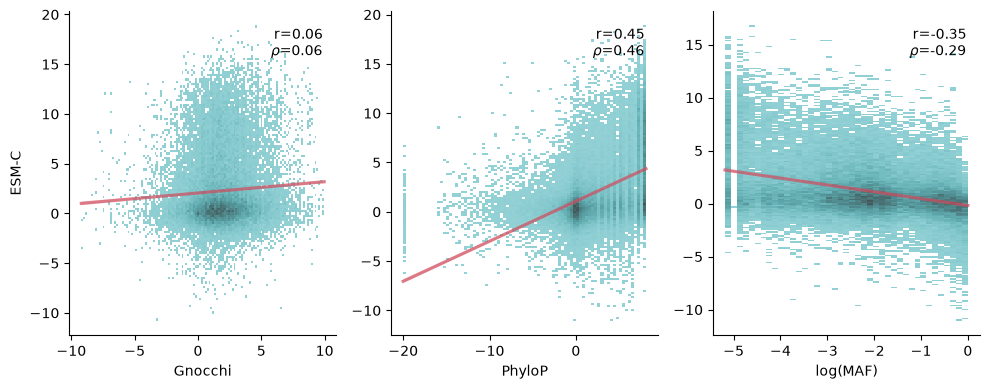

In [31]:
want_annots = {k: v for k, v in annot_names.items() if "roulette" not in k}
corr_model_vs_annotations(
    data=df,
    model_col="esmc_score",
    model_name="ESM-C",
    clip=False,
    annotations=want_annots,
)

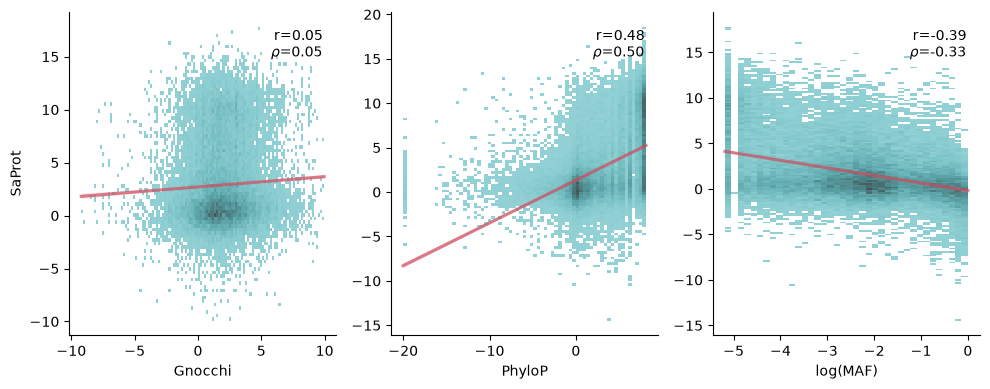

In [32]:
corr_model_vs_annotations(
    data=df,
    model_col="saprot_score",
    model_name="SaProt",
    clip=False,
    annotations=want_annots,
)

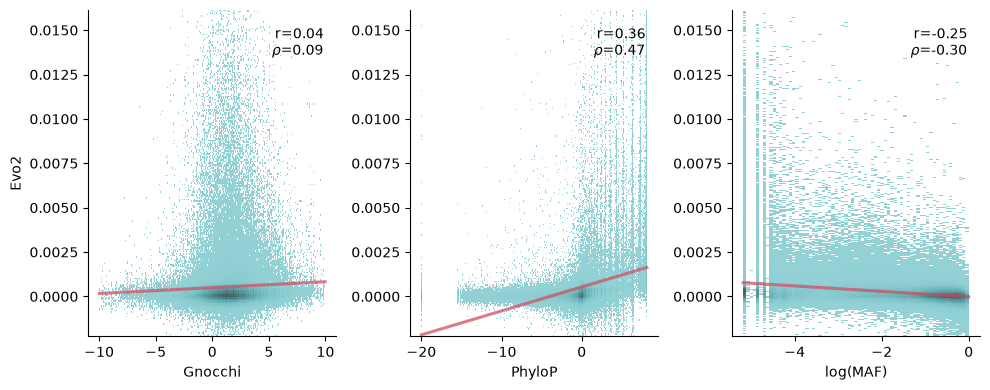

In [16]:
corr_model_vs_annotations(
    # data=df.sample(fraction=0.1),
    data=df,
    model_col="evo_score",
    model_name="Evo2",
    clip=True,
    annotations=want_annots,
)

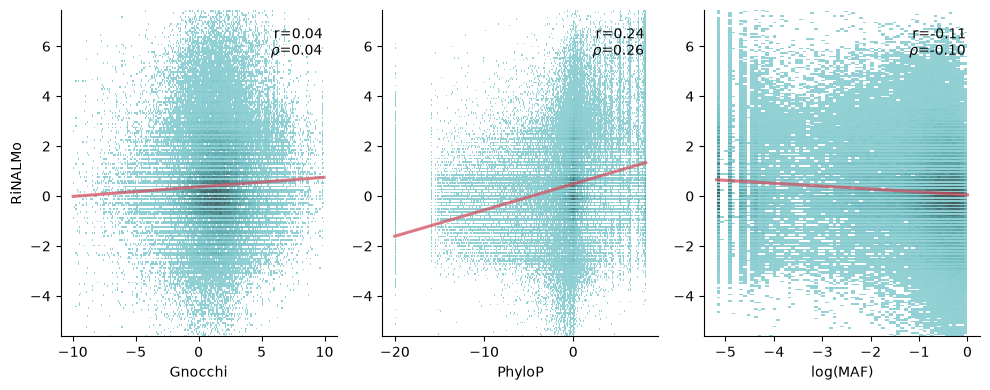

In [17]:
corr_model_vs_annotations(
    # data=df.sample(fraction=0.1),
    data=df,
    model_col="rinalmo_score",
    model_name="RiNALMo",
    # clip=True,
    annotations=want_annots,
)

340507 -> 191022


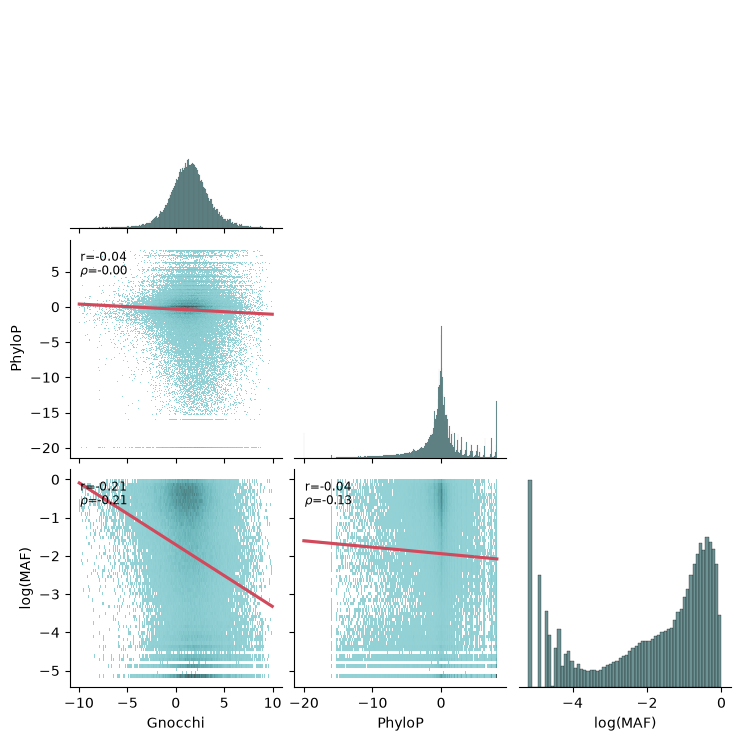

In [18]:
plot_data = df.filter(
    pl.all_horizontal(pl.col(*annot_names.keys()).is_not_null())
).select([k for k in annot_names if "roulette" not in k])
print(f"{len(df)} -> {len(plot_data)}")

g = sns.pairplot(
    plot_data.to_pandas(),
    corner=True,
    markers=".",
    kind="hist",
    diag_kws={"color": hist_color},
    plot_kws={"color": hist_color},
)
g.map_lower(sns.regplot, scatter=False, color=fit_color)

for i, row in enumerate(g.axes):
    for j, ax in enumerate(row):
        if ax is None:
            continue

        xvar = ax.get_xlabel()
        yvar = ax.get_ylabel()
        if xvar == "" or yvar == "":
            continue

        xvals = plot_data.get_column(xvar).to_numpy()
        yvals = plot_data.get_column(yvar).to_numpy()

        r = pearsonr(xvals, yvals)
        rho = spearmanrho(xvals, yvals)
        ax.text(
            0.05,
            0.95,
            s=(
                f"r={r.statistic:0.2f}"
                "\n"
                rf"$\rho$={rho.statistic:0.2f}"
            ),
            transform=ax.transAxes,
            ha="left",
            va="top",
            size="small",
        )

        if i == len(annot_names) - 2:
            ax.set_xlabel(annot_names[xvar])
        if j == 0:
            ax.set_ylabel(annot_names[yvar])

last = g.axes[-1][-1]
last.set_xlabel(annot_names[last.get_xlabel()])
g.tight_layout()


### eQTLs for GWAS hits

In [19]:
(
    df.with_columns(eqtl_label=pl.format("eqtl_{}", "eqtl_label")).pivot(
        on="eqtl_label",
        index="gwas_label",
        values="eqtl_label",
        aggregate_function="len",
    )
)

gwas_label,null,eqtl_low_pip,eqtl_high_pip
str,u32,u32,u32
"""low_pip""",99809,22437,3117
"""high_pip""",1522,47,165
null,160756,44828,7826


In [20]:
(df.filter(pl.col("ukbb_label").is_null(), pl.col("multisusie_label").is_null()).head())

variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log,log_roulette_mr,gwas_pip,gwas_label,evo_ref_prob,evo_alt_prob,evo_score,rinalmo_score,esmc_score
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,str,f64,f64,f64,f64,f64
"""chr1:135203:G:A""","""ENSG00000308579""","""chr1""","""G""","""A""","""ENST00000835176""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""gnomADg_AMI""",135202,135203,508,null,null,0.06026,0.04113,0.09773,null,null,null,null,0.9994909,"""high_pip""","""ENSG00000308579""",0.939095,"""Whole_Blood""","""Lung,Spleen,Testis,Whole_Blood""",null,null,null,null,0.096,null,1.966,null,"""low""",-1.385841,0.293584,null,null,0.559292,0.559184,0.000192,null,null
"""chr1:263722:C:G""","""ENSG00000292994""","""chr1""","""C""","""G""","""ENST00000424587""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""gnomADg_AFR""",263721,263722,4896,null,null,0.125,0.2196,0.4322,null,null,null,null,0.9999956,"""high_pip""","""ENSG00000292994""",0.708986,"""Thyroid""","""Thyroid""",null,null,null,null,-0.152,null,0.051,null,"""low""",-0.658368,-1.29243,null,null,0.366771,0.366496,0.000749,0.125,null
"""chr1:267812:C:T""","""ENSG00000292994""","""chr1""","""C""","""T""","""ENST00000424587""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""gnomADg_SAS""",267811,267812,806,null,null,null,0.02357,0.05624,null,null,null,null,0.9635084,"""high_pip""","""ENSG00000292994""",-2.532786,"""Adipose_Subcutaneous""","""Adipose_Subcutaneous,Brain_Amy…",null,null,null,null,0.421,null,1.897,null,"""low""",-1.62764,0.278067,null,null,0.351818,0.351894,-0.000214,-2.875,null
"""chr1:267879:G:C""","""ENSG00000292994""","""chr1""","""G""","""C""","""ENST00000424587""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""gnomADg_AFR""",267878,267879,739,null,null,null,0.03144,0.09231,null,null,null,null,0.069417,"""low_pip""","""ENSG00000292994""",null,"""Brain_Spinal_cord_cervical_c-1""","""Brain_Spinal_cord_cervical_c-1""",null,null,null,null,0.428,null,0.02,null,"""low""",-1.502517,-1.69897,null,null,0.350959,0.35081,0.000424,-0.25,null
"""chr1:502653:G:T""","""ENSG00000290385""","""chr1""","""G""","""T""","""ENST00000641063""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""gnomADe_AFR""",502652,502653,268,null,null,0.02113,0.08702,0.5,null,null,null,null,0.5897274,"""high_pip""","""ENSG00000290385""",-0.774438,"""Whole_Blood""","""Whole_Blood""",null,null,null,null,0.096,null,0.03,null,"""low""",-1.060381,-1.522879,null,null,0.475459,0.474631,0.001741,null,null


In [21]:
gwas_data = df.filter(pl.col("gwas_label").is_not_null())
gwas_eqtl_data = gwas_data.filter(pl.col("eqtl_label").is_not_null())
print(f"{len(gwas_data)} -> {len(gwas_eqtl_data)}")

127097 -> 25766


In [22]:
roc_auc_score(
    y_true=(gwas_eqtl_data.get_column("gwas_label") == "high_pip").cast(pl.UInt8),
    y_score=gwas_eqtl_data.get_column("eqtl_pip"),
)

0.8548413385786076

### Model classification of binned annotations

In [23]:
flip = ["log_roulette_mr", "gnomadg_af_log"]
results = []
for model, model_name in model_names.items():
    for annot, annot_name in annot_names.items():
        if "roulette" in annot:
            continue
        want_data = df.filter(
            pl.col(model).is_not_null(),
            pl.col(annot).is_not_null(),
        )
        low_thresh, high_thresh = want_data.get_column(annot).quantile([0.25, 0.75])

        high_label = 0 if annot in flip else 1
        low_label = 1 if annot in flip else 0

        labeled_data = want_data.with_columns(
            label=(
                pl.when(pl.col(annot) <= low_thresh)
                .then(low_label)
                .otherwise(
                    pl.when(pl.col(annot) >= high_thresh)
                    .then(high_label)
                    .otherwise(None)
                )
            )
        ).filter(pl.col("label").is_not_null())
        y_true = labeled_data.get_column("label")
        y_score = labeled_data.get_column(model)
        results.append(
            {
                "model": model_name,
                "annotation": annot_name,
                "auroc": roc_auc_score(y_true=y_true, y_score=y_score),
                "auprc": average_precision_score(y_true=y_true, y_score=y_score),
                "num_pos": y_true.sum(),
                "num_neg": len(y_true) - y_true.sum(),
            }
        )
results = pl.DataFrame(results)
results

model,annotation,auroc,auprc,num_pos,num_neg
str,str,f64,f64,i64,i64
"""Evo2""","""Gnocchi""",0.573601,0.556654,54637,54636
"""Evo2""","""PhyloP""",0.836938,0.865454,79830,79847
"""Evo2""","""log(MAF)""",0.709958,0.729112,67030,67025
"""RiNALMo""","""Gnocchi""",0.530539,0.521978,39210,39209
"""RiNALMo""","""PhyloP""",0.685191,0.697607,57686,57695
"""RiNALMo""","""log(MAF)""",0.57234,0.569392,49385,49396
"""ESM-C""","""Gnocchi""",0.543,0.544932,8475,8476
"""ESM-C""","""PhyloP""",0.84217,0.869027,12122,12131
"""ESM-C""","""log(MAF)""",0.708719,0.733369,10084,10081


## Univariate dataset performance

In [24]:
df.head()

variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log,log_roulette_mr,gwas_pip,gwas_label,evo_ref_prob,evo_alt_prob,evo_score,rinalmo_score,esmc_score
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,str,f64,f64,f64,f64,f64
"""chr1:834583:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",834582,834583,204,null,null,null,0.1158,0.3403,0.004209,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.612,null,1.273,null,"""low""",-0.936291,0.104828,0.004209,"""low_pip""",0.314054,0.314115,-0.000196,-1.25,null
"""chr1:835506:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",835505,835506,113,null,null,null,0.1093,0.3085,0.004478,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-2.742,null,2.12,null,"""low""",-0.96138,0.326336,0.004478,"""low_pip""",0.336628,0.33667,-0.000124,-0.375,null
"""chr1:841852:C:T""","""ENSG00000228794""","""chr1""","""C""","""T""","""ENST00000415295""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""SAS""",841851,841852,726,null,null,0.0843,0.06921,0.1493,0.003612,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.459,null,0.094,null,"""low""",-1.159831,-1.026872,0.003612,"""low_pip""",0.329573,0.329497,0.000231,1.25,null
"""chr1:856473:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""gnomADe_FIN""",856472,856473,2884,null,null,0.07955,0.07915,0.1923,0.002221,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.166,1.535938,0.105,null,"""low""",-1.101549,-0.978811,0.002221,"""low_pip""",0.318683,0.318626,0.000177,null,null
"""chr1:858952:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""EAS""",858951,858952,5363,null,null,0.02083,0.09489,0.1607,0.002458,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.531,null,0.916,null,"""low""",-1.02278,-0.038105,0.002458,"""low_pip""",0.306684,0.306683,0.000003,null,null


In [25]:
def raw_score_comparison(
    data: pl.DataFrame,
    dataset_labels: dict[str, list[str]] = dataset_labels,
    scores: list[str] = list(annot_names.keys()) + list(model_names.keys()),
    title: str | None = None,
) -> pl.DataFrame:

    want_data = data.with_columns(
        **{
            f"{dataset}": pl.col(f"{dataset}_label").is_in(pos_labels).cast(pl.UInt8)
            for dataset, pos_labels in dataset_labels.items()
        }
    ).filter(pl.all_horizontal(pl.col(*scores).is_not_null()))

    metrics = []
    for dataset in dataset_labels:
        ds_data = want_data.filter(pl.col(dataset).is_not_null())
        y_true = ds_data.get_column(dataset)
        print(f"{dataset}: {y_true.sum()} / {len(y_true)}")

        for score in scores:
            y_pred = ds_data.get_column(score)
            metrics.append(
                {
                    "dataset": dataset,
                    "score": score,
                    "auroc": roc_auc_score(y_true=y_true, y_score=y_pred),
                    "auprc": average_precision_score(y_true=y_true, y_score=y_pred),
                }
            )

    score_rename = {}
    score_rename.update(annot_names)
    score_rename.update(model_names)
    metrics = (
        pl.DataFrame(metrics)
        .with_columns(
            score=pl.col("score").replace(score_rename),
            dataset=pl.col("dataset").replace(dataset_names),
        )
        .unpivot(
            on=["auroc", "auprc"],
            index=["dataset", "score"],
            variable_name="metric",
            value_name="value",
        )
    )

    fg = sns.FacetGrid(data=metrics, col="metric", aspect=1.5, height=5, sharey=False)
    fg.map_dataframe(sns.barplot, x="dataset", hue="score", y="value", palette="muted")
    fg.set_titles("")
    fg.add_legend()

    auroc_ax = fg.axes[0][0]
    auroc_ax.set_ylim(0.4)
    auroc_ax.axhline(y=0.5, linestyle="--", alpha=0.6, color="black")
    auroc_ax.set_ylabel("AUROC")
    fg.axes[0][1].set_ylabel("AUPRC")

    if title is not None:
        plt.suptitle(title)
    plt.tight_layout()

    # plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
    # plt.axhline(y=0.5, linestyle="--", alpha=0.6, color="black")
    # plt.ylim(0.4)
    # plt.show()

    # sns.barplot(
    #     x="dataset",
    #     hue="score",
    #     y="auprc",
    #     data=metrics,
    # )

    return metrics

In [26]:
def raw_score_comparison_simple(
    data: pl.DataFrame,
    dataset_labels: dict[str, list[str]] = dataset_labels,
    scores: list[str] = list(annot_names.keys()) + list(model_names.keys()),
    title: str | None = None,
) -> pl.DataFrame:

    want_data = data.with_columns(
        **{
            f"{dataset}": pl.col(f"{dataset}_label").is_in(pos_labels).cast(pl.UInt8)
            for dataset, pos_labels in dataset_labels.items()
        }
    ).filter(pl.all_horizontal(pl.col(*scores).is_not_null()))

    metrics = []
    for dataset in dataset_labels:
        ds_data = want_data.filter(pl.col(dataset).is_not_null())
        y_true = ds_data.get_column(dataset)
        print(f"{dataset}: {y_true.sum()} / {len(y_true)}")

        for score in scores:
            y_pred = ds_data.get_column(score)
            metrics.append(
                {
                    "dataset": dataset,
                    "score": score,
                    "auroc": roc_auc_score(y_true=y_true, y_score=y_pred),
                    "auprc": average_precision_score(y_true=y_true, y_score=y_pred),
                }
            )

    score_rename = {}
    score_rename.update(annot_names)
    score_rename.update(model_names)
    metrics = pl.DataFrame(metrics).with_columns(
        score=pl.col("score").replace(score_rename),
        dataset=pl.col("dataset").replace(dataset_names),
    )
    ax = sns.barplot(
        x="dataset",
        hue="score",
        y="auroc",
        legend=True,
        data=metrics,
    )
    plt.legend(title="Model")

    ax.set_ylim(0.4)
    ax.axhline(y=0.5, linestyle="--", alpha=0.6, color="black")
    ax.set_ylabel("AUROC")
    sns.despine()

    if title is not None:
        plt.title(title)
    plt.tight_layout()

    return metrics

gwas: 377 / 6514
eqtl: 318 / 2600
clinvar: 1360 / 12820


dataset,score,metric,value
str,str,str,f64
"""GWAS""","""Gnocchi""","""auroc""",0.545355
"""GWAS""","""PhyloP""","""auroc""",0.687411
"""GWAS""","""log(Roulette MR)""","""auroc""",0.56665
"""GWAS""","""log(MAF)""","""auroc""",0.552197
"""GWAS""","""Evo2""","""auroc""",0.656173
"""GWAS""","""RiNALMo""","""auroc""",0.489774
"""GWAS""","""ESM-C""","""auroc""",0.61925
"""eQTL""","""Gnocchi""","""auroc""",0.566183
…,…,…,…


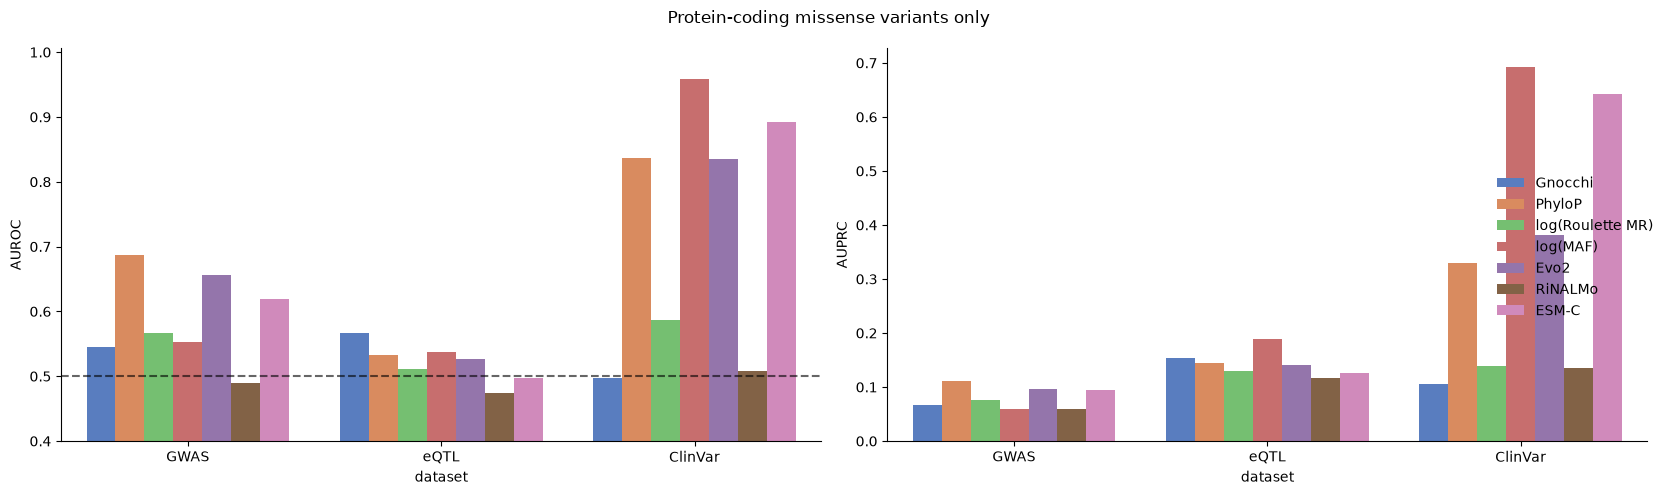

In [27]:
raw_score_comparison(
    df.with_columns(gnomadg_af_log=-pl.col("gnomadg_af_log")),
    title="Protein-coding missense variants only",
)


gwas: 377 / 6531
eqtl: 318 / 2600
clinvar: 5291 / 16910


dataset,score,auroc,auprc
str,str,f64,f64
"""GWAS""","""PhyloP""",0.687285,0.110302
"""GWAS""","""Gnocchi""",0.544895,0.06614
"""GWAS""","""Evo2""",0.655869,0.09567
"""GWAS""","""RiNALMo""",0.489399,0.05937
"""GWAS""","""ESM-C""",0.619221,0.094577
"""eQTL""","""PhyloP""",0.532755,0.143649
"""eQTL""","""Gnocchi""",0.566183,0.15465
"""eQTL""","""Evo2""",0.526495,0.140075
"""eQTL""","""RiNALMo""",0.474783,0.116207


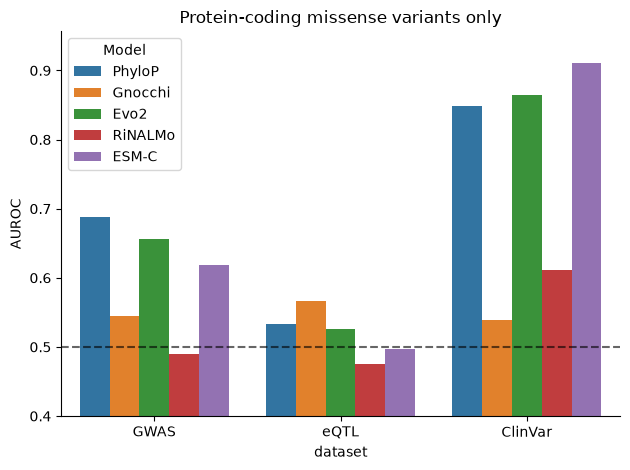

In [28]:
raw_score_comparison_simple(
    df.with_columns(gnomadg_af_log=-pl.col("gnomadg_af_log")),
    title="Protein-coding missense variants only",
    scores=["phylop", "gnocchi_z", "evo_score", "rinalmo_score", "esmc_score"],
)


gwas: 851 / 63629
eqtl: 4332 / 36694
clinvar: 2949 / 49118


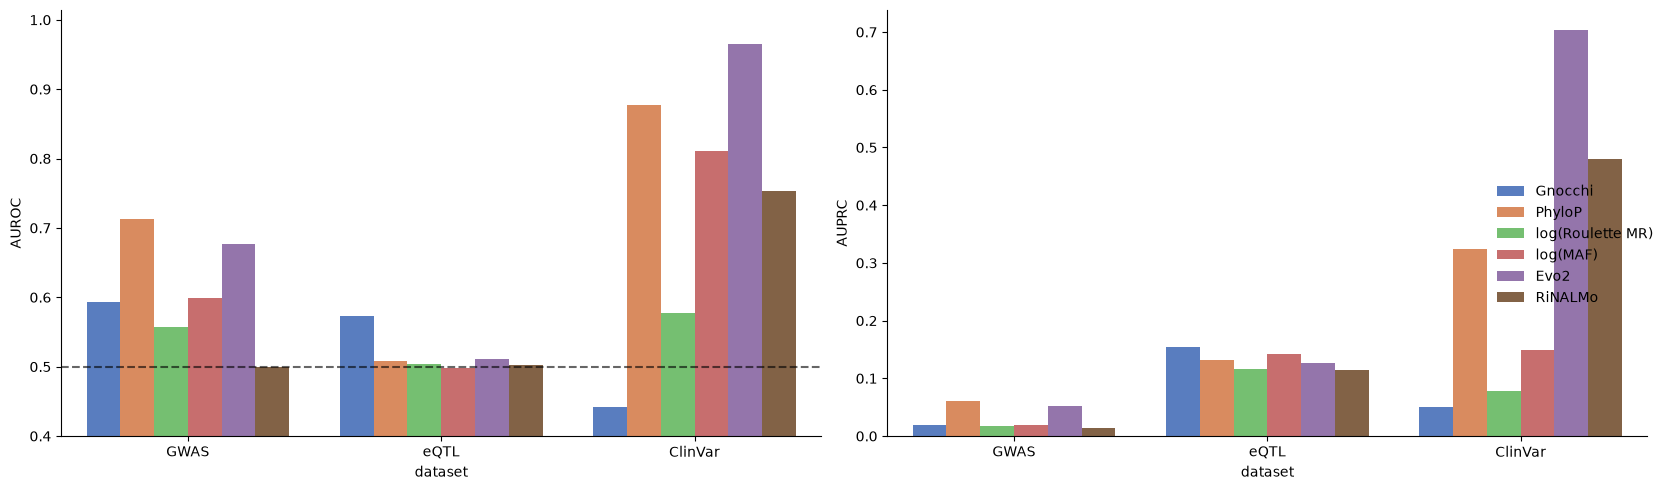

In [29]:
gw_metrics = raw_score_comparison(
    df.with_columns(gnomadg_af_log=-pl.col("gnomadg_af_log")),
    scores=list(annot_names.keys()) + ["evo_score", "rinalmo_score"],
)

gwas: 851 / 63739
eqtl: 4332 / 36697
clinvar: 11320 / 73024


dataset,score,auroc,auprc
str,str,f64,f64
"""GWAS""","""PhyloP""",0.712186,0.061443
"""GWAS""","""Gnocchi""",0.593575,0.019607
"""GWAS""","""Evo2""",0.676385,0.052315
"""GWAS""","""RiNALMo""",0.499746,0.013311
"""eQTL""","""PhyloP""",0.508417,0.131023
"""eQTL""","""Gnocchi""",0.573391,0.155012
"""eQTL""","""Evo2""",0.511765,0.126502
"""eQTL""","""RiNALMo""",0.501904,0.114934
"""ClinVar""","""PhyloP""",0.895016,0.645469


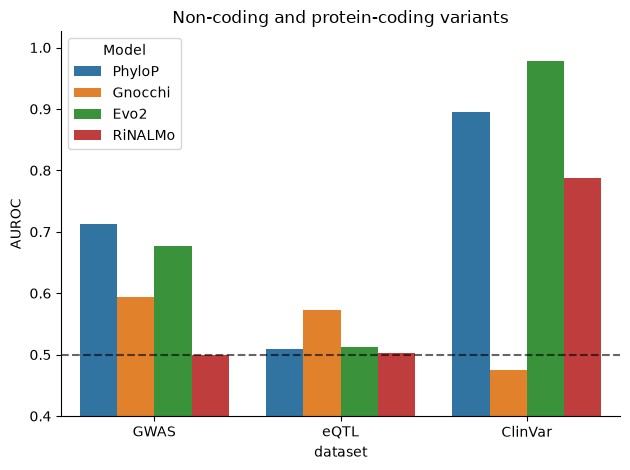

In [30]:
raw_score_comparison_simple(
    df.with_columns(gnomadg_af_log=-pl.col("gnomadg_af_log")),
    scores=["phylop", "gnocchi_z", "evo_score", "rinalmo_score"],
    title="Non-coding and protein-coding variants",
)

In [31]:
want_data = (
    df.with_columns(
        **{
            f"{dataset}": pl.col(f"{dataset}_label").is_in(pos_labels).cast(pl.UInt8)
            for dataset, pos_labels in dataset_labels.items()
        }
    )
    .select(*annot_names, *dataset_labels)
    .unpivot(
        on=[*annot_names],
        variable_name="annotation",
        value_name="score",
        index=[*dataset_labels],
    )
    .unpivot(
        on=[*dataset_labels],
        index=["annotation", "score"],
        variable_name="dataset",
        value_name="label",
    )
    .filter(pl.col("score").is_not_null(), pl.col("label").is_not_null())
)

want_data.head()

annotation,score,dataset,label
str,f64,str,u8
"""gnocchi_z""",1.535938,"""gwas""",0
"""gnocchi_z""",4.937684,"""gwas""",0
"""gnocchi_z""",1.509945,"""gwas""",0
"""gnocchi_z""",3.233242,"""gwas""",0
"""gnocchi_z""",3.233242,"""gwas""",0


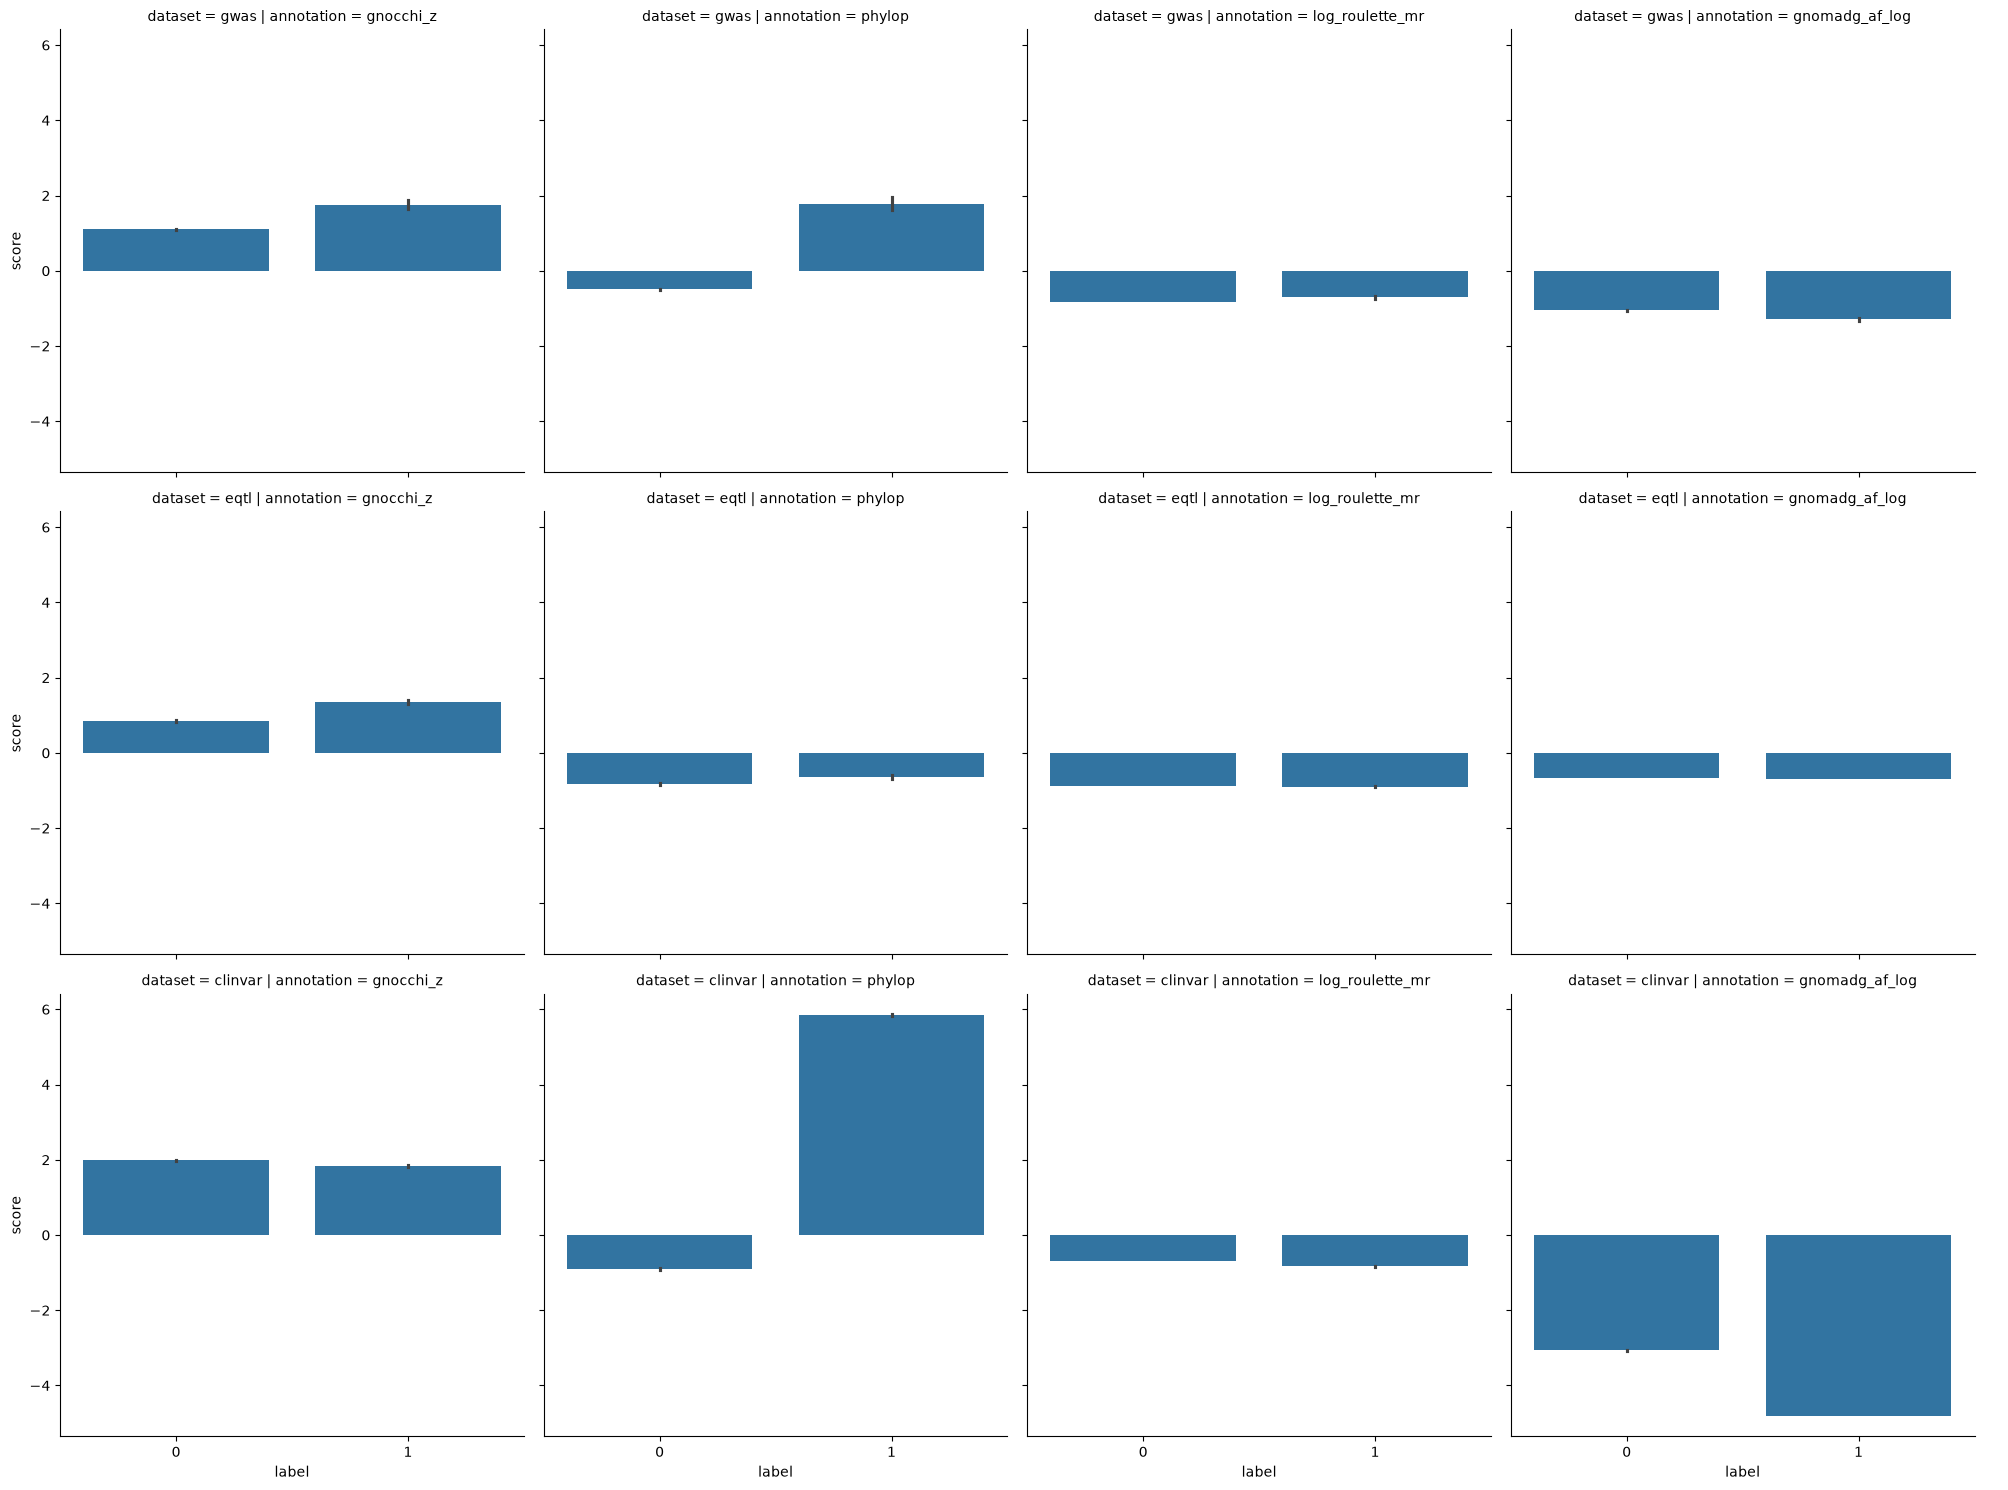

In [32]:
sns.catplot(
    x="label",
    y="score",
    col="annotation",
    row="dataset",
    kind="bar",
    data=want_data,
)

## Complementarity

In [33]:
def prepare_labeled_data(
    data: pl.DataFrame,
    feature_cols: list[str],
    label_columns: list[str],
) -> pl.DataFrame:
    """Collapse labels to single binary 0/1 labels."""
    return data.filter(
        pl.all_horizontal(pl.col(feature_cols).is_not_null()),
        pl.any_horizontal(pl.col(label_columns).is_not_null()),
    ).with_columns(
        label=pl.any_horizontal(
            (pl.col(label_columns) == "high_pip").fill_null(False),
            (pl.col(label_columns).str.contains("athogenic")).fill_null(False),
        ).cast(pl.Int8),
    )


def select_biotype_group(
    data: pl.DataFrame,
    biotype: Literal["all", "protein_coding", "lncRNA"],
) -> pl.DataFrame:
    return data if biotype == "all" else data.filter(pl.col("biotype") == biotype)


def cv_eval_models(
    full_data: pl.DataFrame,
    label_cols: list[str],
    models: dict[str, Any],
    cv: StratifiedGroupKFold,
    shared_variants_only: bool = False,
) -> tuple[pl.DataFrame, np.ndarray, dict[str, np.ndarray]]:
    if shared_variants_only:
        all_features = list(
            {feat_name for features, _ in models.values() for feat_name in features}
        )
        full_data = prepare_labeled_data(
            data=full_data,
            feature_cols=all_features,
            label_columns=label_cols,
        )

    predictions = {}
    metrics = []
    for model_name, (features, model) in models.items():
        labeled_data = prepare_labeled_data(
            data=full_data,
            feature_cols=features,
            label_columns=label_cols,
        )

        groups = labeled_data.get_column("variant").to_numpy()
        y = labeled_data.get_column("label").to_numpy()

        prediction = cross_val_predict(
            model,
            labeled_data.select(features).to_numpy(),
            y,
            groups=groups,
            cv=cv,
            method="predict_proba",
            n_jobs=2,
        )[:, 1]
        predictions[model_name] = prediction
        metrics.append(
            {
                "model": model_name,
                "auroc": roc_auc_score(y, prediction),
                "auprc": average_precision_score(y, prediction),
            }
        )
    return pl.DataFrame(metrics), y, predictions


def eval_all_datasets(
    full_data: pl.DataFrame,
    dataset_specs: dict[str, list[str]],
    want_biotypes: list[str],
    model_specs: dict[str, Any],
    n_folds: int = 5,
    shared_variants_only: bool = False,
) -> tuple[pl.DataFrame, dict[str, np.ndarray], dict[str, np.ndarray]]:
    complementarity_cv = StratifiedGroupKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=42,
    )

    oof_predictions = {}
    oof_outcomes = {}
    model_metrics = []
    for dataset, label_columns in dataset_specs.items():
        for biotype in want_biotypes:
            data = select_biotype_group(full_data, biotype)
            metrics, _y, _predictions = cv_eval_models(
                full_data=data,
                label_cols=label_columns,
                models=model_specs,
                cv=complementarity_cv,
                shared_variants_only=shared_variants_only,
            )
            key = (dataset, biotype)
            oof_outcomes[key] = _y
            oof_predictions[key] = _predictions
            model_metrics.append(
                metrics.with_columns(dataset=pl.lit(dataset), biotype=pl.lit(biotype))
            )
    model_metrics = pl.concat(model_metrics).sort(
        "dataset", "biotype", "auroc", descending=[False, False, True]
    )
    return model_metrics, oof_predictions, oof_outcomes


In [34]:
dataset_specs = {
    "GWAS": ["ukbb_label", "multisusie_label"],
    "eQTL": ["eqtl_label"],
    "All": ["ukbb_label", "multisusie_label", "eqtl_label"],
    "ClinVar": ["clinvar_label"],
}
analysis_biotypes = ["all", "protein_coding", "lncRNA"]

group_sizes = pl.DataFrame(
    [
        {
            "dataset": _dataset,
            "biotype": _biotype,
            "variants": len(_data),
            "high_pip": _data.get_column("label").sum(),
            "low_pip": len(_data) - _data.get_column("label").sum(),
        }
        for _dataset, _label_columns in dataset_specs.items()
        for _biotype in analysis_biotypes
        for _data in [
            select_biotype_group(
                prepare_labeled_data(df, ["phylop", "gnocchi_z"], _label_columns),
                _biotype,
            )
        ]
    ]
)
group_sizes

dataset,biotype,variants,high_pip,low_pip
str,str,i64,i64,i64
"""GWAS""","""all""",84564,1159,83405
"""GWAS""","""protein_coding""",55096,926,54170
"""GWAS""","""lncRNA""",29468,233,29235
"""eQTL""","""all""",50236,6527,43709
"""eQTL""","""protein_coding""",34701,3883,30818
"""eQTL""","""lncRNA""",15535,2644,12891
"""All""","""all""",118071,7593,110478
"""All""","""protein_coding""",77187,4736,72451
"""All""","""lncRNA""",40884,2857,38027


In [35]:
lr_cv_params = {
    "l1_ratios": (0.0,),
    "scoring": "neg_log_loss",
    "use_legacy_attributes": False,
    "n_jobs": 8,
}

linear_model = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(**lr_cv_params),
)

interaction_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LogisticRegressionCV(**lr_cv_params),
)

model_specs = {
    "PhyloP": (["phylop"], linear_model),
    "Gnocchi": (["gnocchi_z"], linear_model),
    "Evo2": (["evo_score"], linear_model),
    "RiNALMo": (["rinalmo_score"], linear_model),
    "ESM-C": (["esmc_score"], linear_model),
    # "additive": (["phylop", "gnocchi_z"], linear_model),
    "interaction": (["phylop", "gnocchi_z"], interaction_model),
    "interaction_roulette": (
        ["phylop", "gnocchi_z", "log_roulette_mr"],
        interaction_model,
    ),
    "evo_gnocchi": (["evo_score", "gnocchi_z"], interaction_model),
    "evo_roulette": (["evo_score", "log_roulette_mr"], interaction_model),
    "evo_phylop": (["evo_score", "phylop"], interaction_model),
    "evo_constraint": (
        ["evo_score", "gnocchi_z", "log_roulette_mr"],
        interaction_model,
    ),
    "evo_gnocchi_phylop": (["evo_score", "gnocchi_z", "phylop"], interaction_model),
    "evo_all": (
        ["evo_score", "gnocchi_z", "phylop", "log_roulette_mr"],
        interaction_model,
    ),
    "rinalmo_gnocchi": (["rinalmo_score", "gnocchi_z"], interaction_model),
    "rinalmo_roulette": (["rinalmo_score", "log_roulette_mr"], interaction_model),
    "rinalmo_phylop": (["rinalmo_score", "phylop"], interaction_model),
    "rinalmo_constraint": (
        ["rinalmo_score", "gnocchi_z", "log_roulette_mr"],
        interaction_model,
    ),
    "rinalmo_gnocchi_phylop": (
        ["rinalmo_score", "gnocchi_z", "phylop"],
        interaction_model,
    ),
    "rinalmo_all": (
        ["rinalmo_score", "gnocchi_z", "phylop", "log_roulette_mr"],
        interaction_model,
    ),
    "esmc_gnocchi": (["esmc_score", "gnocchi_z"], interaction_model),
    "esmc_roulette": (["esmc_score", "log_roulette_mr"], interaction_model),
    "esmc_phylop": (["esmc_score", "phylop"], interaction_model),
    "esmc_constraint": (
        ["esmc_score", "gnocchi_z", "log_roulette_mr"],
        interaction_model,
    ),
    "esmc_gnocchi_phylop": (["esmc_score", "gnocchi_z", "phylop"], interaction_model),
    "esmc_all": (
        ["esmc_score", "gnocchi_z", "phylop", "log_roulette_mr"],
        interaction_model,
    ),
    # Underperforms the additive or interaction models across the board
    # "tree": (
    #     ["phylop", "gnocchi_z"],
    #     make_pipeline(
    #         PolynomialFeatures(degree=2, include_bias=False),
    #         StandardScaler(),
    #         GridSearchCV(
    #             estimator=HistGradientBoostingClassifier(),
    #             param_grid={
    #                 "max_depth": [None, 4, 8],
    #                 "max_iter": [50, 100],
    #             },
    #             n_jobs=8,
    #         ),
    #     ),
    # ),
}


In [63]:
regen = True

In [ ]:
# Missense variants only, due to inclusion of ESM-C as a model
if regen:
    ms_perf_metrics, ms_all_preds, ms_all_labels = eval_all_datasets(
        full_data=df,
        dataset_specs=dataset_specs,
        want_biotypes=["all"],
        model_specs=model_specs,
        shared_variants_only=True,
    )

    with open(
        cache_dir / "classification" / "missense_preds.pkl",
        "wb",
    ) as fh:
        dump((ms_perf_metrics, ms_all_preds, ms_all_labels), fh)

else:
    with open(
        cache_dir / "classification" / "missense_preds.pkl",
        "rb",
    ) as fh:
        ms_perf_metrics, ms_all_preds, ms_all_labels = load(fh)

ms_perf_metrics.head()

model,auroc,auprc,dataset,biotype
str,f64,f64,str,str
"""rinalmo_all""",0.585885,0.111315,"""All""","""all"""
"""esmc_all""",0.583983,0.110376,"""All""","""all"""
"""esmc_phylop""",0.582076,0.114275,"""All""","""all"""
"""rinalmo_gnocchi_phylop""",0.581574,0.107791,"""All""","""all"""
"""PhyloP""",0.57941,0.107588,"""All""","""all"""


In [37]:
# All variants, excluding ESM-C as a model
if regen:
    genome_wide_models = {
        name: spec for name, spec in model_specs.items() if "esm" not in name.lower()
    }
    gw_perf_metrics, gw_all_preds, gw_all_labels = eval_all_datasets(
        full_data=df,
        dataset_specs=dataset_specs,
        want_biotypes=["all"],
        model_specs=genome_wide_models,
        shared_variants_only=True,
    )
    with open(
        cache_dir / "classification" / "genome_wide_preds.pkl",
        "wb",
    ) as fh:
        dump((gw_perf_metrics, gw_all_preds, gw_all_labels), fh)

else:
    with open(
        cache_dir / "classification" / "genome_wide_preds.pkl",
        "rb",
    ) as fh:
        gw_perf_metrics, gw_all_preds, gw_all_labels = load(fh)

gw_perf_metrics.head()

model,auroc,auprc,dataset,biotype
str,f64,f64,str,str
"""rinalmo_all""",0.577614,0.078885,"""All""","""all"""
"""evo_all""",0.575366,0.07965,"""All""","""all"""
"""rinalmo_gnocchi_phylop""",0.573333,0.077946,"""All""","""all"""
"""interaction_roulette""",0.572676,0.078113,"""All""","""all"""
"""evo_gnocchi_phylop""",0.570754,0.078732,"""All""","""all"""


In [72]:
def sample_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    job_idx: int,
    num_bootstraps: int = 100,
) -> dict[str, list[float]]:
    """Bootstrapped estimates of AUROC and AUPRC"""
    rng = np.random.RandomState(seed=42 + job_idx)

    results = defaultdict(list)
    for i in range(num_bootstraps):
        y_true_sample, y_pred_sample = resample(y_true, y_pred, random_state=rng)
        results["auroc"].append(
            roc_auc_score(y_true=y_true_sample, y_score=y_pred_sample)
        )
        results["auprc"].append(
            average_precision_score(y_true=y_true_sample, y_score=y_pred_sample)
        )

    return results


def sample_metric_deltas(
    y_pred_ref: np.ndarray,
    y_pred_oth: np.ndarray,
    y_true: np.ndarray,
    job_idx: int,
    num_bootstraps: int = 100,
) -> dict[str, list[float]]:
    """Bootstrapped estimates of AUROC delta between two models."""
    rng = np.random.RandomState(seed=42 + job_idx)

    results = defaultdict(list)
    for i in range(num_bootstraps):
        y_ref, y_oth, y_t = resample(y_pred_ref, y_pred_oth, y_true, random_state=rng)

        auroc_ref = roc_auc_score(y_t, y_ref)
        auroc_oth = roc_auc_score(y_t, y_oth)
        results["auroc"].append(auroc_oth - auroc_ref)
        results["auroc_pct"].append(100 * (auroc_oth - auroc_ref) / auroc_ref)

        auprc_ref = average_precision_score(y_t, y_ref)
        auprc_oth = average_precision_score(y_t, y_oth)
        results["auprc"].append(auprc_oth - auprc_ref)
        results["auprc_pct"].append(100 * (auprc_oth - auprc_ref) / auprc_ref)
    return results


def nested_metrics_to_df(
    x: list[dict[str, list[str]]],
    index_items: dict[str, str],
) -> pl.DataFrame:
    flat = defaultdict(list)
    for d in x:
        for k, l in d.items():
            flat[k].extend(l)

    flat.update(index_items)
    return pl.DataFrame(flat)


def run_bootstrap_estimates(
    preds: dict[tuple[str, str], dict[str, np.ndarray]],
    labels: dict[tuple[str, str], np.ndarray],
    comparisons=list[tuple[str, tuple[str]]],
    n_jobs: int = 8,
    num_bootstraps_per_job: int = 100,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    seen = set()
    bootstrapped_metrics = []
    bootstrapped_diffs = []

    with Pool(processes=n_jobs) as p:
        for (dataset, biotype), y_true in labels.items():
            for ref_model, compare_models in comparisons:
                y_ref = preds[(dataset, biotype)][ref_model]

                metric_func = partial(sample_metrics, y_true, y_ref)
                bootstrapped_metrics.append(
                    nested_metrics_to_df(
                        x=p.map(metric_func, range(n_jobs)),
                        index_items={"model": ref_model, "dataset": dataset},
                    )
                )

                for compare_model in compare_models:
                    y_oth = preds[(dataset, biotype)][compare_model]

                    if (compare_model, dataset) not in seen:
                        metric_func = partial(sample_metrics, y_true, y_oth)
                        bootstrapped_metrics.append(
                            nested_metrics_to_df(
                                x=p.map(metric_func, range(n_jobs)),
                                index_items={
                                    "model": compare_model,
                                    "dataset": dataset,
                                },
                            )
                        )
                        seen.add((compare_model, dataset))

                    metric_func = partial(sample_metric_deltas, y_ref, y_oth, y_true)
                    bootstrapped_diffs.append(
                        nested_metrics_to_df(
                            x=p.map(metric_func, range(n_jobs)),
                            index_items={
                                "ref": ref_model,
                                "compare": compare_model,
                                "dataset": dataset,
                            },
                        )
                    )
    return pl.concat(bootstrapped_metrics), pl.concat(bootstrapped_diffs)

In [73]:
ms_delta_comparisons = [
    (
        "Evo2",
        (
            "evo_gnocchi",
            "evo_roulette",
            "evo_phylop",
            "evo_constraint",
            "evo_gnocchi_phylop",
            "evo_all",
        ),
    ),
    (
        "RiNALMo",
        (
            "rinalmo_gnocchi",
            "rinalmo_roulette",
            "rinalmo_phylop",
            "rinalmo_constraint",
            "rinalmo_gnocchi_phylop",
            "rinalmo_all",
        ),
    ),
    (
        "ESM-C",
        (
            "esmc_gnocchi",
            "esmc_roulette",
            "esmc_phylop",
            "esmc_constraint",
            "esmc_gnocchi_phylop",
            "esmc_all",
        ),
    ),
    ("PhyloP", ("interaction", "interaction_roulette")),
]

gw_delta_comparisons = [
    (
        "Evo2",
        (
            "evo_gnocchi",
            "evo_roulette",
            "evo_phylop",
            "evo_constraint",
            "evo_gnocchi_phylop",
            "evo_all",
        ),
    ),
    (
        "RiNALMo",
        (
            "rinalmo_gnocchi",
            "rinalmo_roulette",
            "rinalmo_phylop",
            "rinalmo_constraint",
            "rinalmo_gnocchi_phylop",
            "rinalmo_all",
        ),
    ),
    ("PhyloP", ("interaction", "interaction_roulette")),
]

In [74]:
if regen:
    ms_bootstrap_metrics, ms_bootstrap_diffs = run_bootstrap_estimates(
        preds=ms_all_preds,
        labels=ms_all_labels,
        comparisons=ms_delta_comparisons,
    )
    with open(
        cache_dir / "classification" / "missense_bootstraps.pkl",
        "wb",
    ) as fh:
        dump((ms_bootstrap_metrics, ms_bootstrap_diffs), fh)

else:
    with open(
        cache_dir / "classification" / "missense_bootstraps.pkl",
        "rb",
    ) as fh:
        ms_bootstrap_metrics, ms_bootstrap_diffs = load(fh)

ms_bootstrap_metrics.head()

auroc,auprc,model,dataset
f64,f64,str,str
0.644346,0.091277,"""Evo2""","""GWAS"""
0.655686,0.089866,"""Evo2""","""GWAS"""
0.642369,0.0898,"""Evo2""","""GWAS"""
0.654833,0.101465,"""Evo2""","""GWAS"""
0.680129,0.101112,"""Evo2""","""GWAS"""


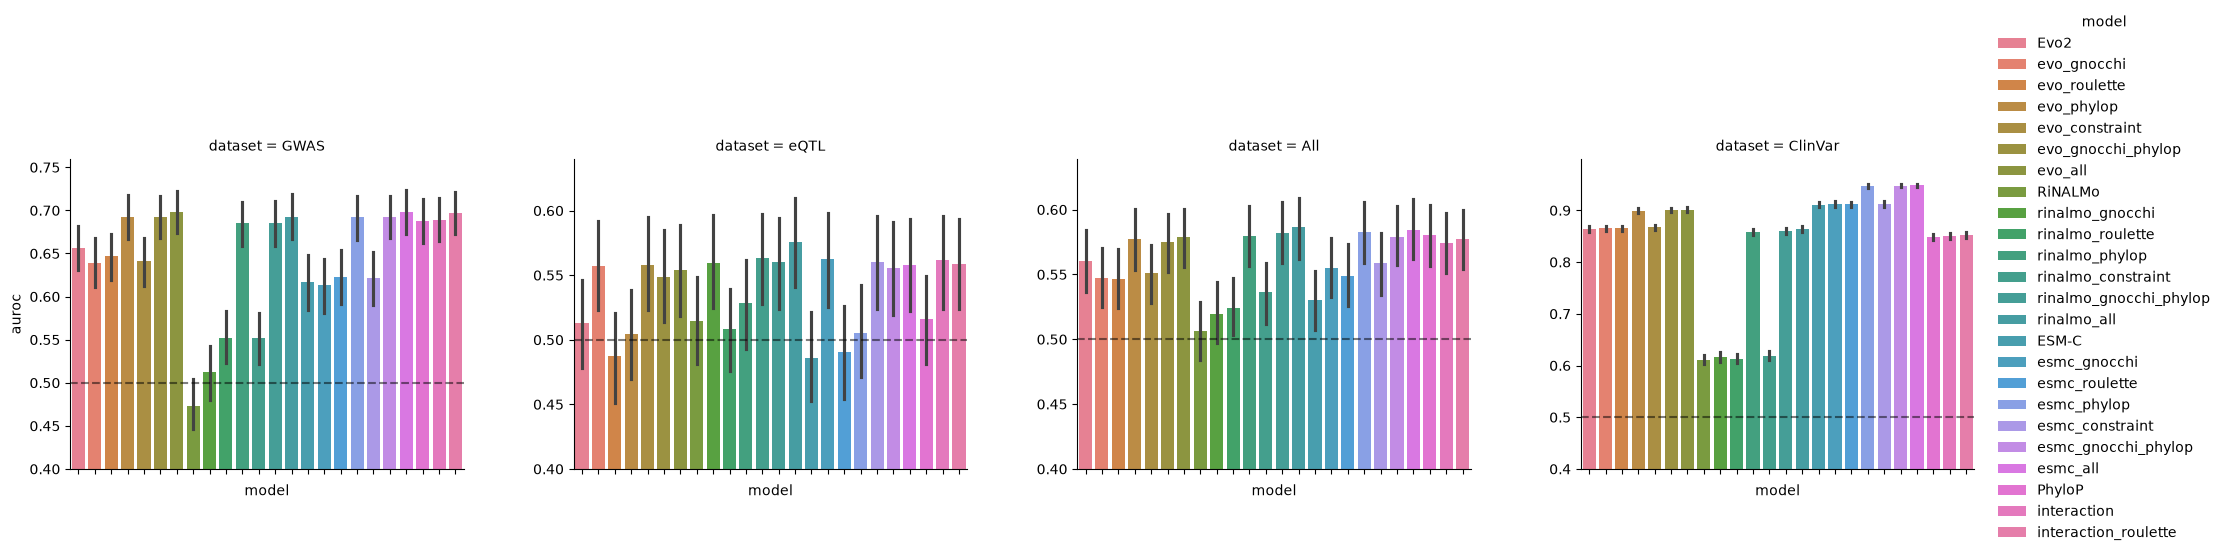

In [41]:
fg = sns.catplot(
    x="model",
    y="auroc",
    hue="model",
    col="dataset",
    sharey=False,
    kind="bar",
    errorbar=("pi", 95),
    data=ms_bootstrap_metrics,
    legend=True,
)
fg.set_xticklabels([])
for row in fg.axes:
    for ax in row:
        ax.set_ylim(0.4)
        ax.axhline(0.5, linestyle="--", alpha=0.5, color="black")

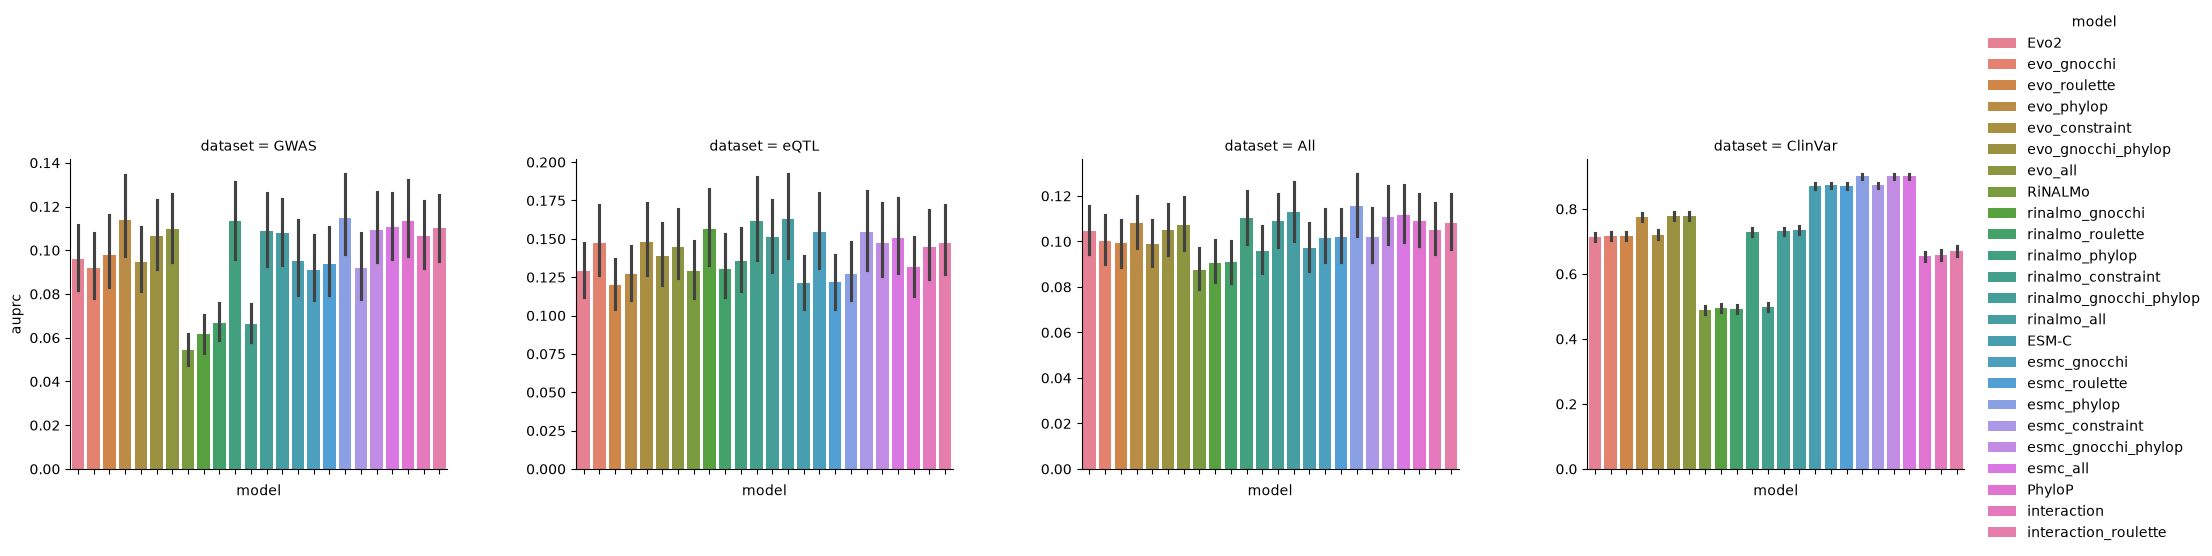

In [42]:
fg = sns.catplot(
    x="model",
    y="auprc",
    hue="model",
    col="dataset",
    sharey=False,
    kind="bar",
    errorbar=("pi", 95),
    data=ms_bootstrap_metrics,
    legend=True,
)
fg.set_xticklabels([])

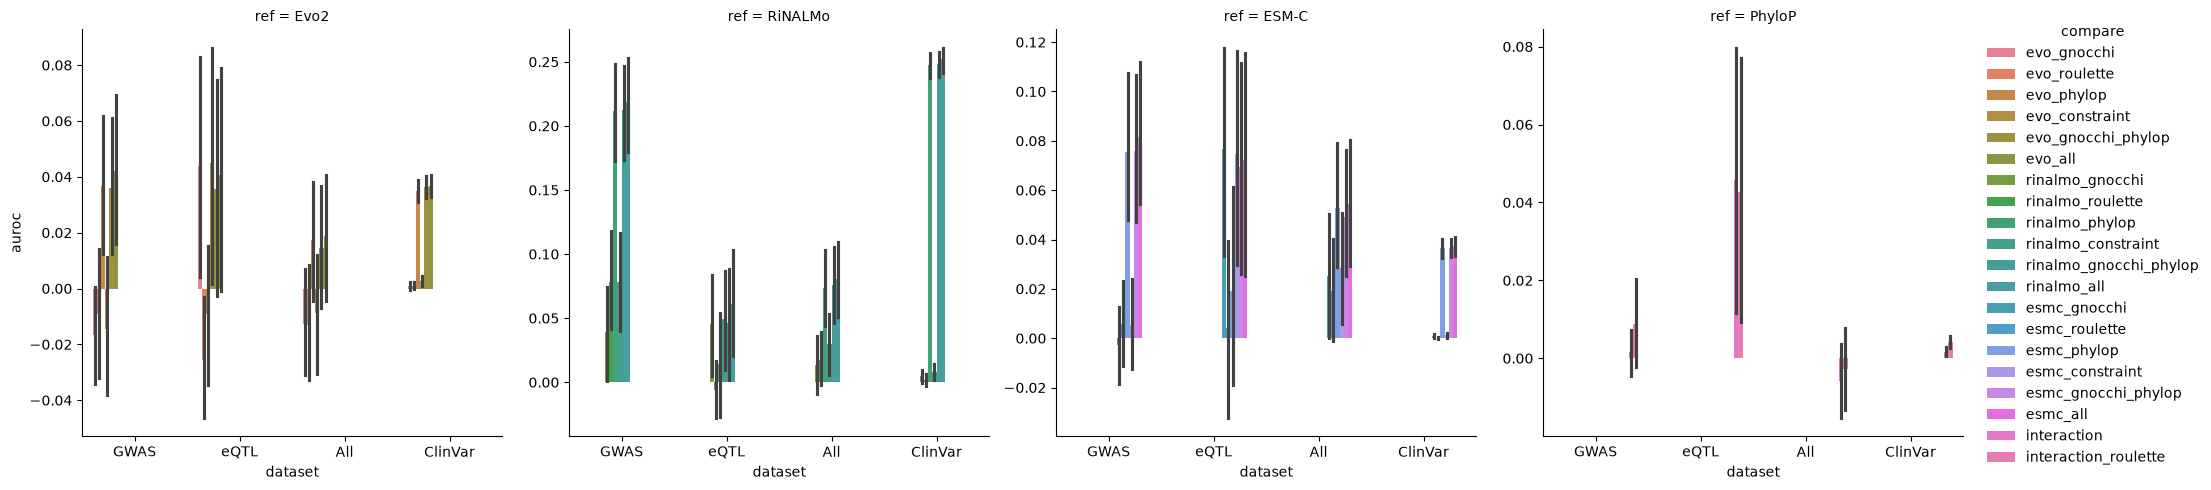

In [43]:
fg = sns.catplot(
    col="ref",
    x="dataset",
    hue="compare",
    y="auroc",
    sharey=False,
    sharex=False,
    kind="bar",
    errorbar=("pi", 95),
    data=ms_bootstrap_diffs,
    legend=True,
)
# fg.set_xticklabels([])

In [ ]:
def feature_list_to_sort_key(
    features: list[str],
    feature_order: list[str],
) -> int:
    return sum([2 ** feature_order.index(x) for x in features])


def plot_feature_comparison(
    data: pl.DataFrame,
    ax: plt.Axes,
    ax_sets: plt.Axes,
    feature_order: list[str],
    title: str | None = None,
):
    """Plot performance bars and corresponding UpSet-style feature matrix."""
    # Restrict to comparisons where all features are in the desired feature set
    specs_to_features = {k: v[0] for k, v in model_specs.items()}
    data = (
        data.with_columns(
            feature_set=pl.col("compare").replace_strict(
                specs_to_features, return_dtype=pl.List
            ),
        )
        .filter(
            pl.col("feature_set").list.set_difference(feature_order).list.len() == 0,
        )
        .drop("feature_set")
    )

    names_and_features = sorted(
        [(name, model_specs[name][0]) for name in data.get_column("compare").unique()],
        key=lambda x: feature_list_to_sort_key(x[1], feature_order),
    )
    names, feature_sets = zip(*names_and_features)

    # Performance
    sns.barplot(
        data=data,
        x="compare",
        y="auroc",
        order=names,
        estimator=np.mean,
        errorbar=("pi", 95),
        ax=ax,
    )

    ax2 = ax.twinx()
    sns.barplot(
        data=data,
        x="compare",
        y="auroc_pct",
        order=names,
        estimator=np.mean,
        errorbar=("pi", 95),
        ax=ax2,
    )

    ax.set_title(title or "")
    ax.set_xlabel("")
    ax.axhline(0, color="0.5", lw=0.75)

    # Feature matrix
    for i, feature_set in enumerate(feature_sets):
        included = set(feature_set)

        for j, feature in enumerate(feature_order):
            ax_sets.scatter(
                i,
                j,
                s=45,
                facecolor="black" if feature in included else "white",
                edgecolor="black",
            )

    ax_sets.set(
        ylim=(-0.5, len(feature_order) - 0.5),
        xticks=[],
        yticks=range(len(feature_order)),
    )
    ax_sets.invert_yaxis()
    ax_sets.tick_params(axis="y", length=0)

    sns.despine(ax=ax)
    sns.despine(ax=ax2, right=False)
    sns.despine(ax=ax_sets, left=True, bottom=True)

    return ax2

In [ ]:
def diffs_upset_plot(
    bootstrap_diffs: pl.DataFrame,
    dataset: str,
    feature_order: list[str] | None = ["phylop", "gnocchi_z"],
    want_refs: list[str] | None = None,
    plot_col: str = "auroc",
):
    plot_data = bootstrap_diffs.filter(pl.col("dataset") == dataset)
    if want_refs is None:
        want_refs = plot_data["ref"].unique().sort().to_list()

    # Determine global feature ordering
    all_names = plot_data["compare"].unique()
    if feature_order is None:
        feature_counts = Counter(f for name in all_names for f in model_specs[name][0])
        feature_order = [
            f for f, _ in feature_counts.most_common() if f not in model_names
        ]

    model_to_score_name = {v: k for k, v in model_names.items()}
    model_to_score_name["Evo"] = "evo_score"

    fig, axs = plt.subplots(
        2,
        len(want_refs),
        figsize=(4 * len(want_refs), 4),
        sharex="col",
        gridspec_kw={
            "height_ratios": [4, 1],
            "hspace": 0.05,
            "wspace": 0.5,
        },
        squeeze=False,
    )

    twin_axes = []
    for i, ref in enumerate(want_refs):
        if ref != "PhyloP":
            this_feature_order = [model_to_score_name[ref]] + feature_order
        else:
            this_feature_order = ["phylop"] + [
                x for x in feature_order if x != "phylop"
            ]
        twin_ax = plot_feature_comparison(
            plot_data.filter(pl.col("ref") == ref),
            ax=axs[0, i],
            ax_sets=axs[1, i],
            feature_order=this_feature_order,
            title=f"ref = {ref}",
        )
        axs[0, i].set_ylabel("")
        twin_ax.set_ylabel("")
        axs[1, i].set_yticklabels([pretty_names.get(f, "") for f in this_feature_order])
        twin_axes.append(twin_ax)

    label = ""
    if plot_col == "auroc":
        label = r"$\Delta$ AUROC"
        label_pct = "% AUROC change"
    elif plot_col == "auroc_pct":
        label = "% AUROC change"
    elif plot_col == "auprc":
        label = r"$\Delta$ AUPRC"
    elif plot_col == "auprc_pct":
        label = "% AUPRC change"

    axs[0, 0].set_ylabel(label)
    twin_axes[-1].set_ylabel(label_pct)

    # if i == 0:
    #     axs[1, i].set_yticklabels([pretty_names[f] for f in feature_order])
    # else:
    #     axs[1, i].set_yticklabels([])
    plt.tight_layout()
    plt.suptitle(f"Dataset = {dataset}")

/tmp/ipykernel_2081315/1241110070.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


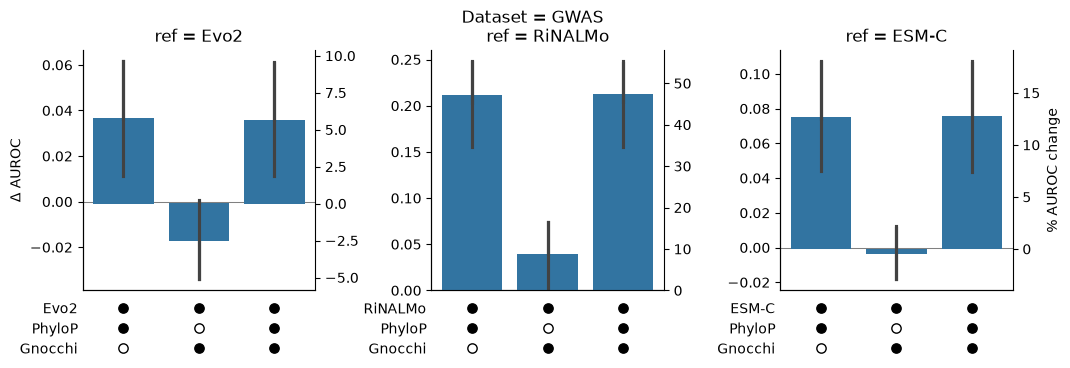

In [99]:
diffs_upset_plot(ms_bootstrap_diffs, "GWAS", want_refs=["Evo2", "RiNALMo", "ESM-C"])

/tmp/ipykernel_2081315/1241110070.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


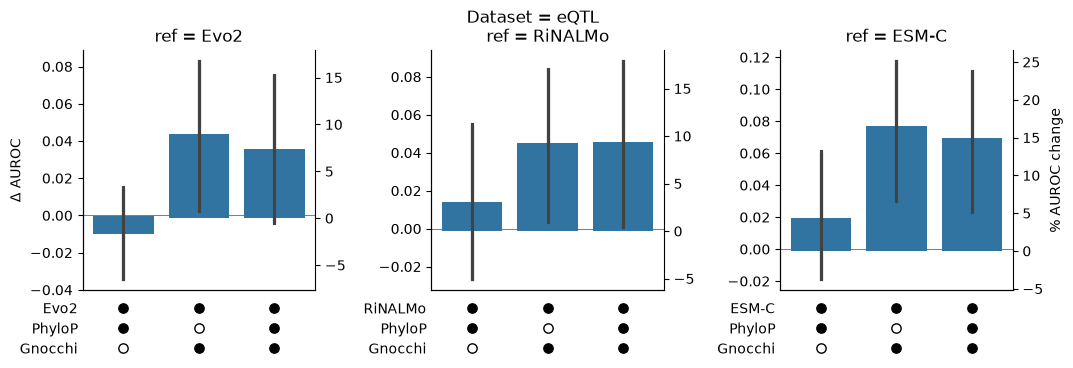

In [100]:
diffs_upset_plot(ms_bootstrap_diffs, "eQTL", want_refs=["Evo2", "RiNALMo", "ESM-C"])

/tmp/ipykernel_2081315/1241110070.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


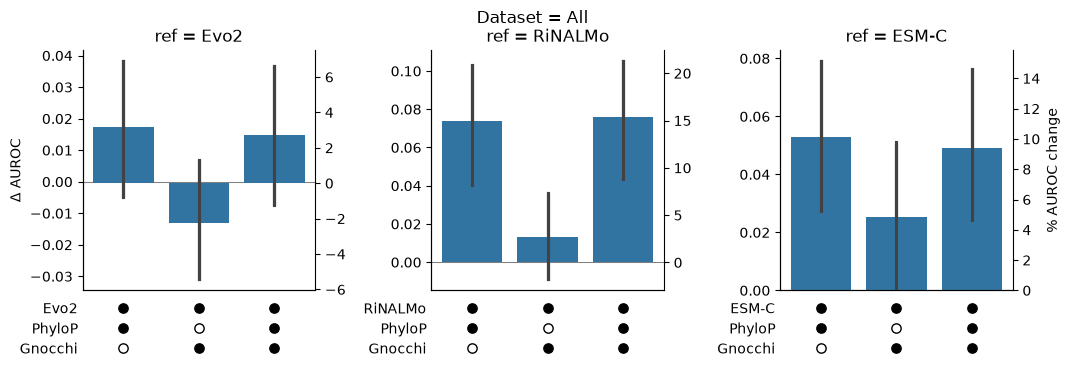

In [101]:
diffs_upset_plot(ms_bootstrap_diffs, "All", want_refs=["Evo2", "RiNALMo", "ESM-C"])

/tmp/ipykernel_2081315/1241110070.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


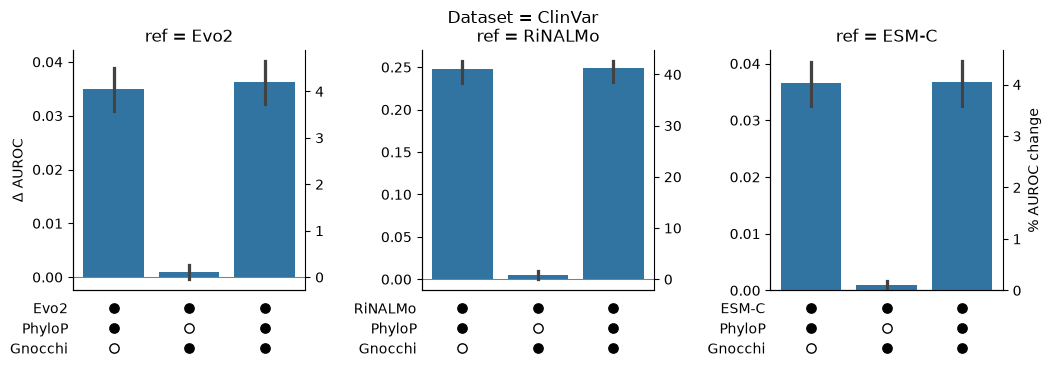

In [102]:
diffs_upset_plot(ms_bootstrap_diffs, "ClinVar", want_refs=["Evo2", "RiNALMo", "ESM-C"])

In [77]:
if regen:
    gw_bootstrap_metrics, gw_bootstrap_diffs = run_bootstrap_estimates(
        preds=gw_all_preds,
        labels=gw_all_labels,
        comparisons=gw_delta_comparisons,
    )
    with open(
        cache_dir / "classification" / "genome_wide_bootstraps.pkl",
        "wb",
    ) as fh:
        dump((gw_bootstrap_metrics, gw_bootstrap_diffs), fh)

else:
    with open(
        cache_dir / "classification" / "genome_wide_bootstraps.pkl",
        "rb",
    ) as fh:
        gw_bootstrap_metrics, gw_bootstrap_diffs = load(fh)

gw_bootstrap_metrics.head()

auroc,auprc,model,dataset
f64,f64,str,str
0.671439,0.049828,"""Evo2""","""GWAS"""
0.686504,0.057972,"""Evo2""","""GWAS"""
0.658243,0.052989,"""Evo2""","""GWAS"""
0.674429,0.052186,"""Evo2""","""GWAS"""
0.671499,0.048172,"""Evo2""","""GWAS"""


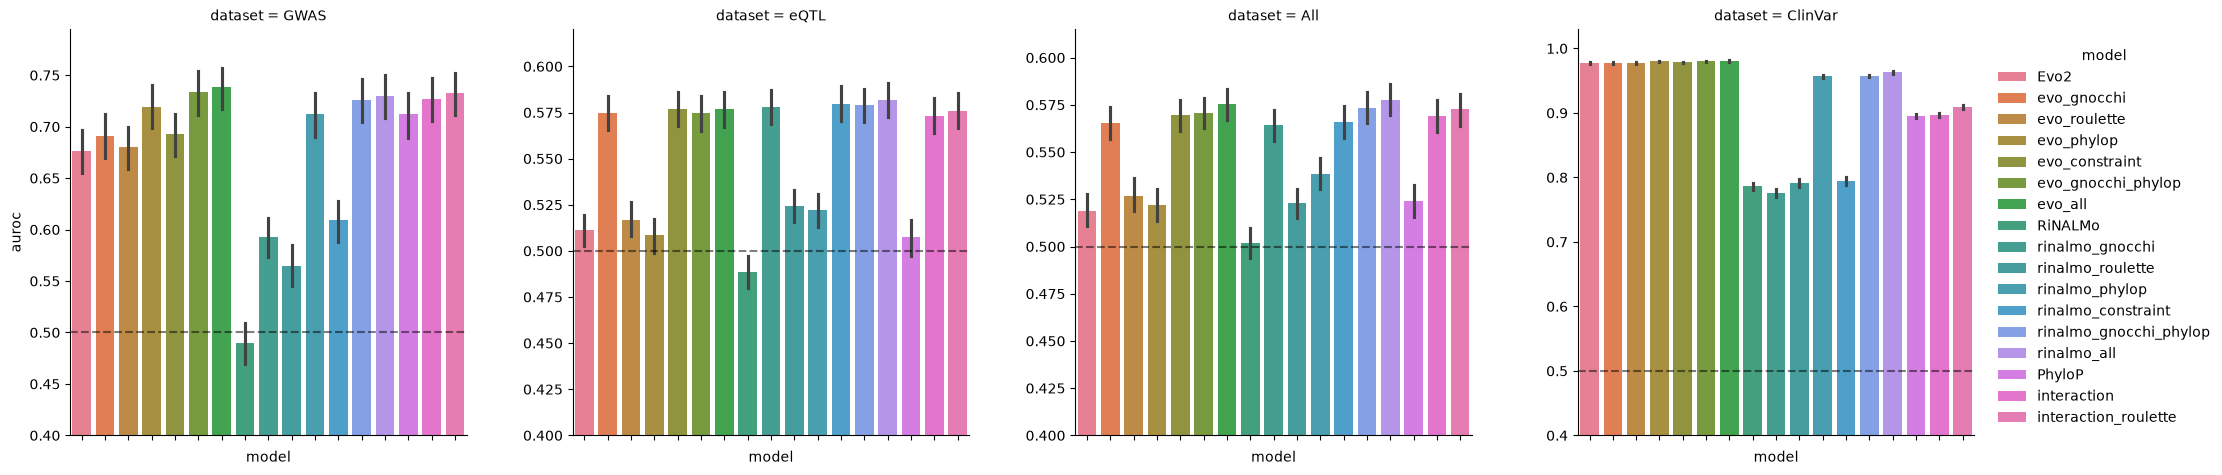

In [78]:
fg = sns.catplot(
    x="model",
    y="auroc",
    hue="model",
    col="dataset",
    sharey=False,
    kind="bar",
    errorbar=("pi", 95),
    data=gw_bootstrap_metrics,
    legend=True,
)
fg.set_xticklabels([])
for row in fg.axes:
    for ax in row:
        ax.set_ylim(0.4)
        ax.axhline(0.5, linestyle="--", alpha=0.5, color="black")

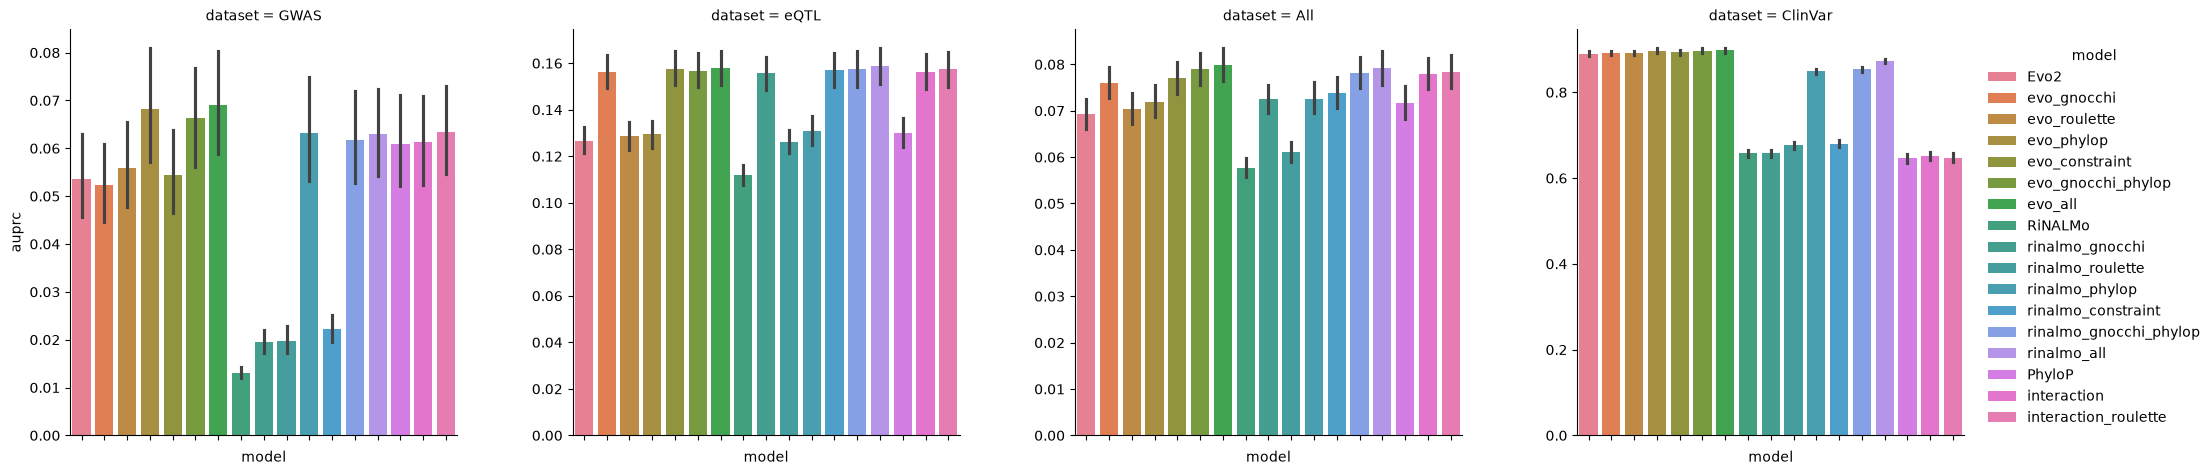

In [79]:
fg = sns.catplot(
    x="model",
    y="auprc",
    hue="model",
    col="dataset",
    sharey=False,
    kind="bar",
    errorbar=("pi", 95),
    data=gw_bootstrap_metrics,
    legend=True,
)
fg.set_xticklabels([])

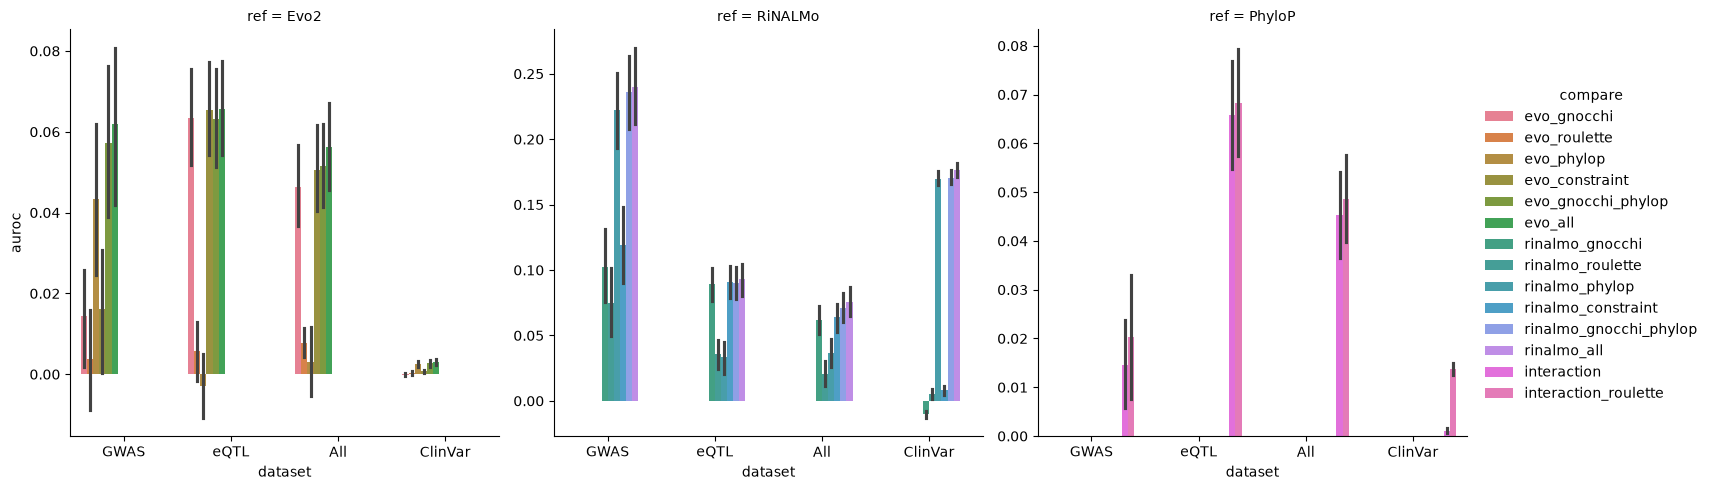

In [80]:
fg = sns.catplot(
    col="ref",
    x="dataset",
    hue="compare",
    y="auroc",
    sharey=False,
    sharex=False,
    kind="bar",
    errorbar=("pi", 95),
    data=gw_bootstrap_diffs,
    legend=True,
)
# fg.set_xticklabels([])

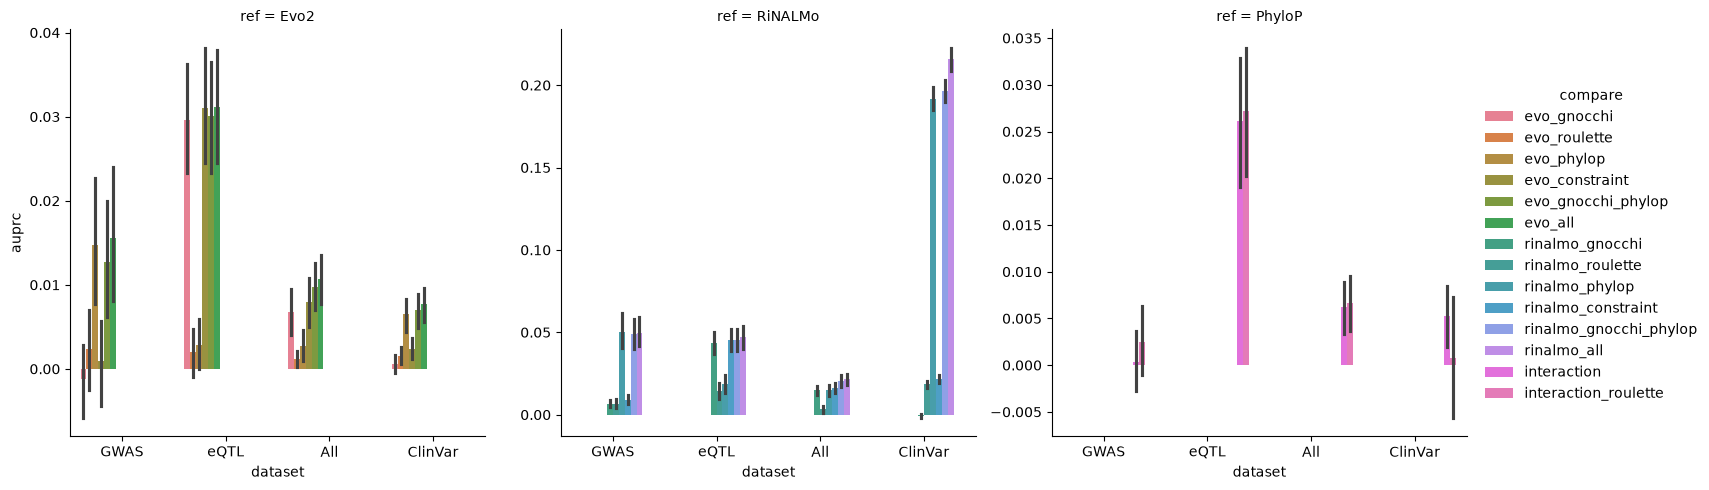

In [81]:
fg = sns.catplot(
    col="ref",
    x="dataset",
    hue="compare",
    y="auprc",
    sharey=False,
    sharex=False,
    kind="bar",
    errorbar=("pi", 95),
    data=gw_bootstrap_diffs,
    legend=True,
)
# fg.set_xticklabels([])

/tmp/ipykernel_2081315/1241110070.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


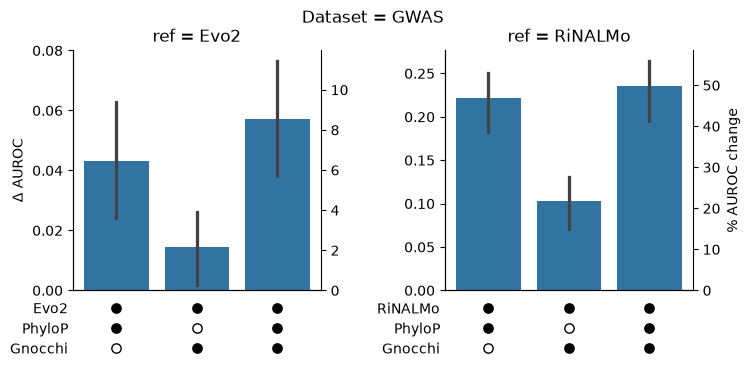

In [104]:
diffs_upset_plot(gw_bootstrap_diffs, "GWAS", want_refs=["Evo2", "RiNALMo"])

/tmp/ipykernel_2081315/1241110070.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


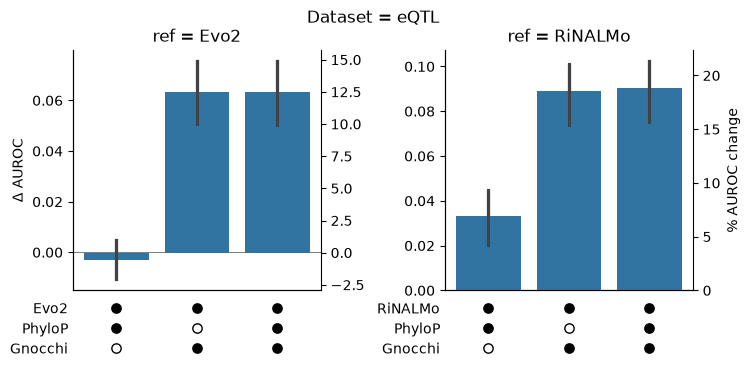

In [106]:
diffs_upset_plot(gw_bootstrap_diffs, "eQTL", want_refs=["Evo2", "RiNALMo"])

/tmp/ipykernel_2081315/1241110070.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


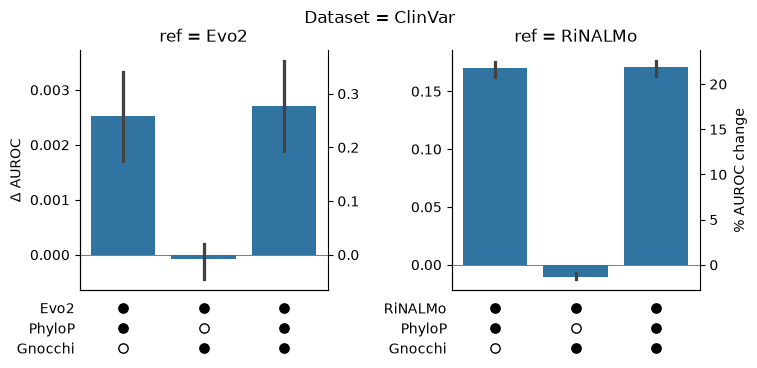

In [107]:
diffs_upset_plot(gw_bootstrap_diffs, "ClinVar", want_refs=["Evo2", "RiNALMo"])

/tmp/ipykernel_2081315/1241110070.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


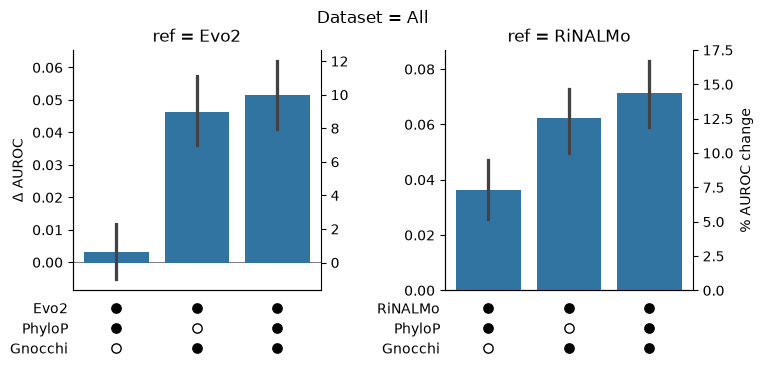

In [108]:
diffs_upset_plot(gw_bootstrap_diffs, "All", want_refs=["Evo2", "RiNALMo"])